# Pipeline MCTNet — California + Arkansas (Table 2)
## ÉTAPE 1 : Alignement CDL → ÉTAPE 2 : Cube spectral 10 bandes → ÉTAPE 3 : MCT-Net
## Deux études de zone séparées dans le même notebook

> **Structure attendue :**
> ```
> data/
>   raw/
>     californiaX.SAFE
>     arkansasX.SAFE
>   processed/
>     cdl_california_2021.tif
>     cdl_arkansas_2021.tif
> models/
> ```


## 📦 Imports

In [5]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
import math
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f'GPU dispo: {"ok " + gpu if gpu else "CPU uniquement"}')
print('Imports OK')


PyTorch  : 2.11.0+cpu
Rasterio : 1.4.4
GPU dispo: CPU uniquement
Imports OK


## ⚙️ Configuration — Auto-discovery des nouvelles images

> **✅ Après avoir téléchargé de nouvelles images avec `download_sentinel2.py` :**
> Il suffit de **relancer cette cellule** — les nouveaux `.SAFE` sont détectés automatiquement dans `data/raw/` et ajoutés aux `DATES_MAP`.
> Aucune modification manuelle du code n'est nécessaire.

> **Structure des fichiers attendue :**
> ```
> data/raw/
>   S2A_MSIL2A_20210315T184921_..._T10SGH_....SAFE/   ← nouveau téléchargé
>   california1.SAFE/   ← existant
>   arkansas1.SAFE/     ← existant
>   ...
> ```

In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres communs ───────────────────────────────────────────────────
N_BANDS           = 10
BANDS_10M         = ['B02', 'B03', 'B04', 'B08']
BANDS_20M         = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS         = BANDS_10M + BANDS_20M
TOTAL_SAMPLES     = 10_000
N_TRAIN_PER_CLASS = 240
N_VAL_PER_CLASS   = 60
BATCH_SIZE        = 1282
LR                = 0.0005
EPOCHS            = 2250
RANDOM_STATE      = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ══════════════════════════════════════════════════════════════════════════════
# 🔍 AUTO-DISCOVERY — Scan automatique des nouveaux .SAFE téléchargés
# ══════════════════════════════════════════════════════════════════════════════

import re
from datetime import date as _date

def _parse_safe(safe_path, verbose=False):
    """
    Extrait (tile, date_str, granule_dir, file_prefix, doy) depuis un .SAFE.
    VERSION ROBUSTE : cherche les jp2 dans toutes les résolutions + log les échecs.
    FALLBACK : si le nom du .SAFE ne contient pas la date/tuile (ex: california1.SAFE),
               tente de les extraire depuis le dossier GRANULE/L2A_T... interne.
    Retourne None si le format n'est pas reconnu.
    """
    name = safe_path.name
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    
    if not m:
        # ── FALLBACK : lire tile+date depuis le dossier GRANULE interne ──────
        granule_root = safe_path / 'GRANULE'
        if not granule_root.exists():
            if verbose: print(f'    ⚠️  Regex non match + GRANULE absent: {name[:60]}')
            return None
        granule_dirs = list(granule_root.glob('L2A_*'))
        if not granule_dirs:
            if verbose: print(f'    ⚠️  Regex non match + aucun L2A_: {name[:60]}')
            return None
        # Ex: L2A_T10SGH_A022833_20210720T185324 => tile=T10SGH, date=20210720
        gname = granule_dirs[0].name
        mg = re.search(r'L2A_(T\d+[A-Z]+)_[A-Z0-9]+_(\d{8})T', gname)
        if not mg:
            if verbose: print(f'    ⚠️  Regex non match (nom + granule): {name[:60]} / {gname[:50]}')
            return None
        tile     = mg.group(1)
        date_str = mg.group(2)
        if verbose: print(f'    ℹ️  Fallback granule OK: {name[:40]} → tile={tile} date={date_str}')
    else:
        date_str = m.group(1)
        tile     = m.group(2)

    try:
        d   = _date(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:8]))
        doy = d.timetuple().tm_yday
    except Exception:
        return None

    # Trouver le dossier GRANULE
    granule_root = safe_path / 'GRANULE'
    if not granule_root.exists():
        if verbose: print(f'    ❌ GRANULE absent: {safe_path.name[:60]}')
        return None
    granule_dirs = list(granule_root.glob('L2A_*'))
    if not granule_dirs:
        if verbose: print(f'    ❌ Aucun L2A_ dans GRANULE: {safe_path.name[:60]}')
        return None
    granule_dir = granule_dirs[0].name

    # Chercher B04 dans toutes les résolutions disponibles (R10m, R20m, R60m)
    img_data = safe_path / 'GRANULE' / granule_dir / 'IMG_DATA'
    jp2s = []
    for res_folder in ['R10m', 'R20m', 'R60m']:
        res_path = img_data / res_folder
        if res_path.exists():
            found = list(res_path.glob('*_B04*.jp2'))
            if found:
                jp2s = found
                break  # priorité R10m

    # Fallback : chercher B04 partout dans IMG_DATA
    if not jp2s and img_data.exists():
        jp2s = list(img_data.rglob('*_B04*.jp2'))

    if not jp2s:
        if verbose: print(f'    ❌ Aucun B04 jp2 dans {safe_path.name[:50]}')
        return None

    # Reconstruire file_prefix depuis le nom du jp2 trouvé
    jp2_name = jp2s[0].name  # ex: T10SGH_20210720T183919_B04_10m.jp2
    parts = jp2_name.split('_')
    file_prefix = '_'.join(parts[:2])  # ex: T10SGH_20210720T183919

    return {'tile': tile, 'date_str': date_str, 'doy': doy,
            'safe_name': safe_path.name, 'granule_dir': granule_dir,
            'file_prefix': file_prefix}


def build_dates_map(safe_dir, tile_to_zone, base_entries, n_total=36, label=''):
    """
    Construit un DATES_MAP dynamique :
    1. Part des entrées de base (acquisitions connues)
    2. Scanne safe_dir pour les nouveaux .SAFE correspondant aux tuiles attendues
    3. Complète avec des placeholders jusqu'à n_total entrées
    4. Trie par DOY pour que l'interpolation soit correcte

    tile_to_zone : dict  ex: {'T10SGH': 'SGH', 'T10SFG': 'SFG', ...}
    base_entries : dict  entrées déjà connues {nom: (safe, granule, prefix, zone)}
    """
    # Construire un index des dates déjà présentes (évite les doublons)
    known_keys = set()
    for safe, granule, prefix, zone in base_entries.values():
        if safe != '__pad__.SAFE':
            known_keys.add(prefix[:19])  # ex: 'T10SGH_20210720T183'

    # Parcourir les .SAFE dans safe_dir
    new_entries = {}
    for safe_path in sorted(Path(safe_dir).glob('*.SAFE')):
        info = _parse_safe(safe_path, verbose=True)
        if info is None:
            continue
        tile = info['tile']
        if tile not in tile_to_zone:
            continue
        key = info['file_prefix'][:19]
        if key in known_keys:
            continue  # déjà dans base_entries

        zone     = tile_to_zone[tile]
        date_str = info['date_str']
        name_key = f"new_{tile.lower()}_{date_str}"
        new_entries[name_key] = (
            safe_path.name,
            info['granule_dir'],
            info['file_prefix'],
            zone,
        )
        known_keys.add(key)

    # Fusionner base + nouveaux
    all_real = {**base_entries, **new_entries}

    # Retirer les placeholders existants dans base_entries
    all_real = {k: v for k, v in all_real.items() if v[0] != '__pad__.SAFE'}

    n_real = len(all_real)
    n_pad  = max(0, n_total - n_real)

    if new_entries:
        print(f'  [{label}] +{len(new_entries)} nouveaux .SAFE détectés : {list(new_entries.keys())}')

    # Trier par DOY (extrait depuis file_prefix)
    def _doy_from_entry(entry):
        prefix = entry[2]  # file_prefix
        try:
            ds = prefix.split('_')[1][:8]
            d  = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
            return d.timetuple().tm_yday
        except Exception:
            return 999

    sorted_real = dict(sorted(all_real.items(), key=lambda x: _doy_from_entry(x[1])))

    # Ajouter les placeholders
    dates_map = dict(sorted_real)
    for i in range(n_pad):
        dates_map[f'pad_{label.lower()}_{n_real+i+1:02d}'] = ('__pad__.SAFE', '__pad__', '__pad__', list(tile_to_zone.values())[0])

    assert len(dates_map) == n_total, f'DATES_MAP {label} : attendu {n_total}, got {len(dates_map)}'
    return dates_map, n_real, n_pad


# ══════════════════════════════════════════════════════════════════════════════
# 🌴 ZONE 1 — CALIFORNIA
# ══════════════════════════════════════════════════════════════════════════════
CDL_CA_INPUT  = PROCESSED_DIR / 'cdl_california_2021.tif'
TRAIN_CSV_CA  = PROCESSED_DIR / 'mctnet_california_360feats.csv'
MODEL_PATH_CA = MODEL_DIR     / 'mctnet_california_final.pth'

CDL_ALIGNED_CA = {
    'SGH': PROCESSED_DIR / 'california_sgh.tif',
    'SFH': PROCESSED_DIR / 'california_sfh.tif',
    'SFG': PROCESSED_DIR / 'california_sfg.tif',
    'SFJ': PROCESSED_DIR / 'california_sfj.tif',
}

S2_REF_CA = {
    'SGH': SAFE_DIR / 'california1.SAFE/GRANULE/L2A_T10SGH_A022833_20210720T185324/IMG_DATA/R10m/T10SGH_20210720T183919_B04_10m.jp2',
    'SFH': SAFE_DIR / 'california10.SAFE/GRANULE/L2A_T10SFH_A022876_20210723T185617/IMG_DATA/R10m/T10SFH_20210723T184919_B04_10m.jp2',
    'SFG': SAFE_DIR / 'california8.SAFE/GRANULE/L2A_T10SFG_A022876_20210723T185617/IMG_DATA/R10m/T10SFG_20210723T184919_B04_10m.jp2',
    'SFJ': SAFE_DIR / 'california9.SAFE/GRANULE/L2A_T10SFJ_A022876_20210723T185617/IMG_DATA/R10m/T10SFJ_20210723T184919_B04_10m.jp2',
}

# ── Acquisitions CA de base (connues) ────────────────────────────────────────
_BASE_CA = {
    'july_sgh':  ('california1.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'jan_sgh':   ('california3.SAFE',  'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641', 'SGH'),
    'sept_sgh':  ('california4.SAFE',  'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959', 'SGH'),
    'jan_sfg':   ('california5.SAFE',  'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641', 'SFG'),
    'sept_sfg':  ('california6.SAFE',  'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131', 'SFG'),
    'apr_sfg':   ('california7.SAFE',  'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911', 'SFG'),
    'july_sfg':  ('california8.SAFE',  'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919', 'SFG'),
    'july_sfj':  ('california9.SAFE',  'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919', 'SFJ'),
    'july_sfh':  ('california10.SAFE', 'L2A_T10SFH_A022876_20210723T185617', 'T10SFH_20210723T184919', 'SFH'),
}
# Note : july_sgh2 retiré — même date que july_sgh (DOY 201), doublon inutile pour l'interpolation

_TILE_ZONE_CA = {'T10SGH': 'SGH', 'T10SFH': 'SFH', 'T10SFG': 'SFG', 'T10SFJ': 'SFJ'}

DATES_MAP_CA, _n_real_ca, _n_pad_ca = build_dates_map(SAFE_DIR, _TILE_ZONE_CA, _BASE_CA, n_total=36, label='CA')

CA_CLASSES = {
    'Grapes'    : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'      : [3, 238],
    'Alfalfa'   : [36, 225, 240],
    'Almonds'   : [68, 243, 254],
    'Pistachios': [76, 204, 244],
}
CA_ORDER     = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
N_CLASSES_CA = len(CA_ORDER)

# ══════════════════════════════════════════════════════════════════════════════
# 🌾 ZONE 2 — ARKANSAS
# ══════════════════════════════════════════════════════════════════════════════
CDL_AR_INPUT  = PROCESSED_DIR / 'cdl_arkansas_2021.tif'
TRAIN_CSV_AR  = PROCESSED_DIR / 'mctnet_arkansas_360feats.csv'
MODEL_PATH_AR = MODEL_DIR     / 'mctnet_arkansas_final.pth'

CDL_ALIGNED_AR = {
    'SXU': PROCESSED_DIR / 'arkansas_sxu.tif',
}

S2_REF_AR = {
    'SXU': SAFE_DIR / 'arkansas1.SAFE/GRANULE/L2A_T15SXU_A032727_20210927T165058/IMG_DATA/R10m/T15SXU_20210927T164051_B04_10m.jp2',
}

# ── Acquisitions AR de base (connues) ────────────────────────────────────────
_BASE_AR = {
    'jan_ar':   ('arkansas4.SAFE', 'L2A_T15SXU_A020215_20210118T170017', 'T15SXU_20210118T165629', 'SXU'),
    'apr_ar':   ('arkansas3.SAFE', 'L2A_T15SXU_A021602_20210425T164719', 'T15SXU_20210425T163829', 'SXU'),
    'sept_ar':  ('arkansas1.SAFE', 'L2A_T15SXU_A032727_20210927T165058', 'T15SXU_20210927T164051', 'SXU'),
}
# Note : sept_ar2 retiré — même date que sept_ar1 (DOY 270), doublon inutile

_TILE_ZONE_AR = {'T15SXU': 'SXU'}

DATES_MAP_AR, _n_real_ar, _n_pad_ar = build_dates_map(SAFE_DIR, _TILE_ZONE_AR, _BASE_AR, n_total=36, label='AR')

AR_CLASSES = {
    'Rice'    : [3, 238],
    'Soybeans': [5],
    'Cotton'  : [2],
    'Corn'    : [1],
}
AR_ORDER     = ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
N_CLASSES_AR = len(AR_ORDER)

# ── Résumé ────────────────────────────────────────────────────────────────────
print('=== Configuration ===')
print(f'  Device  : {DEVICE}')
print(f'  Bandes  : {ALL_BANDS}\n')
print(f'  [CA] Dates réelles : {_n_real_ca}/36  |  Placeholders : {_n_pad_ca}')
print(f'  [CA] Features: 36 × 10 = 360  ✅')
print(f'  [CA] Classes : {CA_ORDER}')
print(f'  [CA] CDL     : {"✅ " + str(CDL_CA_INPUT) if CDL_CA_INPUT.exists() else "❌ MANQUANT"}\n')
print(f'  [AR] Dates réelles : {_n_real_ar}/36  |  Placeholders : {_n_pad_ar}')
print(f'  [AR] Features: 36 × 10 = 360  ✅')
print(f'  [AR] Classes : {AR_ORDER}')
print(f'  [AR] CDL     : {"✅ " + str(CDL_AR_INPUT) if CDL_AR_INPUT.exists() else "❌ MANQUANT"}')


    ℹ️  Fallback granule OK: arkansas1.SAFE → tile=T15SXU date=20210927
    ℹ️  Fallback granule OK: arkansas2.SAFE → tile=T15SXU date=20210927
    ℹ️  Fallback granule OK: arkansas3.SAFE → tile=T15SXU date=20210425
    ℹ️  Fallback granule OK: arkansas4.SAFE → tile=T15SXU date=20210118
    ℹ️  Fallback granule OK: california1.SAFE → tile=T10SGH date=20210720
    ℹ️  Fallback granule OK: california10.SAFE → tile=T10SFH date=20210723
    ℹ️  Fallback granule OK: california2.SAFE → tile=T10SGH date=20210720
    ℹ️  Fallback granule OK: california3.SAFE → tile=T10SGH date=20210126
    ℹ️  Fallback granule OK: california4.SAFE → tile=T10SGH date=20210921
    ℹ️  Fallback granule OK: california5.SAFE → tile=T10SFG date=20210126
    ℹ️  Fallback granule OK: california6.SAFE → tile=T10SFG date=20210926
    ℹ️  Fallback granule OK: california7.SAFE → tile=T10SFG date=20210419
    ℹ️  Fallback granule OK: california8.SAFE → tile=T10SFG date=20210723
    ℹ️  Fallback granule OK: california9.SAFE

---
# ÉTAPE 1 — Alignement CDL
### ✅ FIX : Alignement sur DEUX grilles distinctes (SGH et SFH)

In [7]:
import gc
gc.collect()

def align_cdl_to_s2(s2_ref_path, cdl_input_path, output_path, zone_name):
    """Reprojette le CDL sur la grille exacte d'une tuile Sentinel-2."""
    if not Path(s2_ref_path).exists():
        print(f'  ⚠️  Bande réf introuvable pour {zone_name} — SKIP')
        return None, None, None
    print(f'=== Alignement CDL Zone {zone_name} ===')
    with rasterio.open(s2_ref_path) as s2:
        dst_crs = s2.crs; dst_transform = s2.transform
        profile = s2.profile.copy()
        print(f'  CRS: {dst_crs}  |  Bounds: {s2.bounds}')
    profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})
    if output_path.exists(): output_path.unlink()
    with rasterio.open(cdl_input_path) as src:
        with rasterio.open(output_path, 'w', **profile) as dst:
            reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=dst_transform, dst_crs=dst_crs,
                      resampling=WarpResampling.nearest)
    print(f'✅ CDL {zone_name} aligné → {output_path}\n')
    return profile, dst_transform, dst_crs

def align_all_zones(s2_ref_dict, cdl_input_path, cdl_aligned_dict, label):
    """Aligne le CDL sur toutes les zones d'une étude."""
    print(f'\n{"="*60}')
    print(f'  Alignement CDL — {label}')
    print(f'{"="*60}')
    profiles = {}
    for zone in sorted(s2_ref_dict.keys()):
        p, t, c = align_cdl_to_s2(s2_ref_dict[zone], cdl_input_path, cdl_aligned_dict[zone], zone)
        profiles[zone] = {'ok': p is not None, 'profile': p, 'transform': t, 'crs': c}
    return profiles

# ── California ────────────────────────────────────────────────────────────────
zone_profiles_CA = align_all_zones(S2_REF_CA, CDL_CA_INPUT, CDL_ALIGNED_CA, 'CALIFORNIA')

# ── Arkansas ──────────────────────────────────────────────────────────────────
zone_profiles_AR = align_all_zones(S2_REF_AR, CDL_AR_INPUT, CDL_ALIGNED_AR, 'ARKANSAS')

print('\n=== Résumé alignement ===')
for zone, info in zone_profiles_CA.items(): print(f'  CA-{zone}: {"✅" if info["ok"] else "❌"}')
for zone, info in zone_profiles_AR.items(): print(f'  AR-{zone}: {"✅" if info["ok"] else "❌"}')



  Alignement CDL — CALIFORNIA
=== Alignement CDL Zone SFG ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4090200.0, right=709800.0, top=4200000.0)
✅ CDL SFG aligné → data\processed\california_sfg.tif

=== Alignement CDL Zone SFH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4190220.0, right=709800.0, top=4300020.0)
✅ CDL SFH aligné → data\processed\california_sfh.tif

=== Alignement CDL Zone SFJ ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4290240.0, right=709800.0, top=4400040.0)
✅ CDL SFJ aligné → data\processed\california_sfj.tif

=== Alignement CDL Zone SGH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)
✅ CDL SGH aligné → data\processed\california_sgh.tif


  Alignement CDL — ARKANSAS
=== Alignement CDL Zone SXU ===
  CRS: EPSG:32615  |  Bounds: BoundingBox(left=600000.0, bottom=3790200.0, right=709800.0, top=3900000.0)
✅ CDL SXU aligné → data\processed\

### 🔍 Inspection du CDL aligné

=== California (Zone SGH) ===
  CRS: EPSG:32610  |  Taille: 10980×10980 px
  Classes agricoles: 55  |  Pixels: 120,560,400


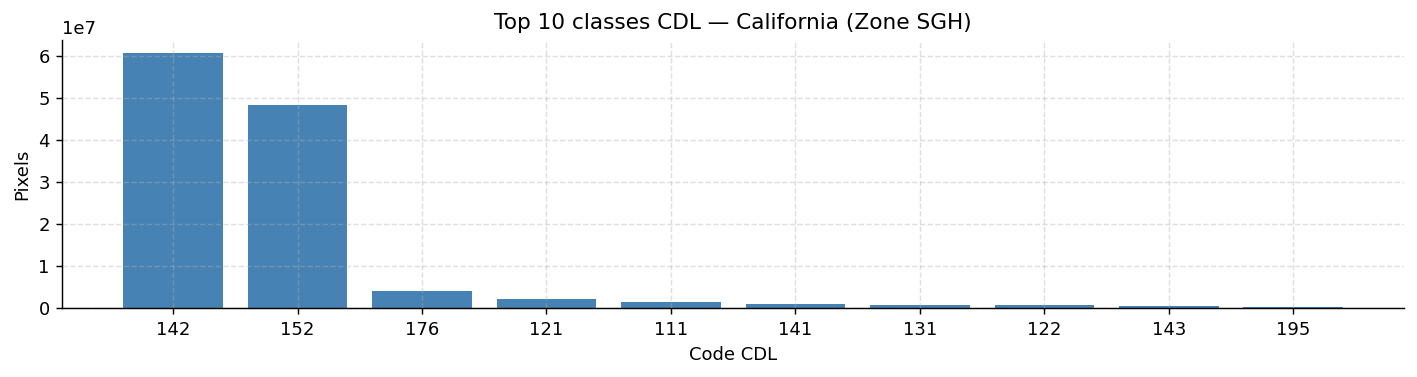

=== Arkansas (Zone SXU) ===
  CRS: EPSG:32615  |  Taille: 10980×10980 px
  Classes agricoles: 43  |  Pixels: 119,683,812


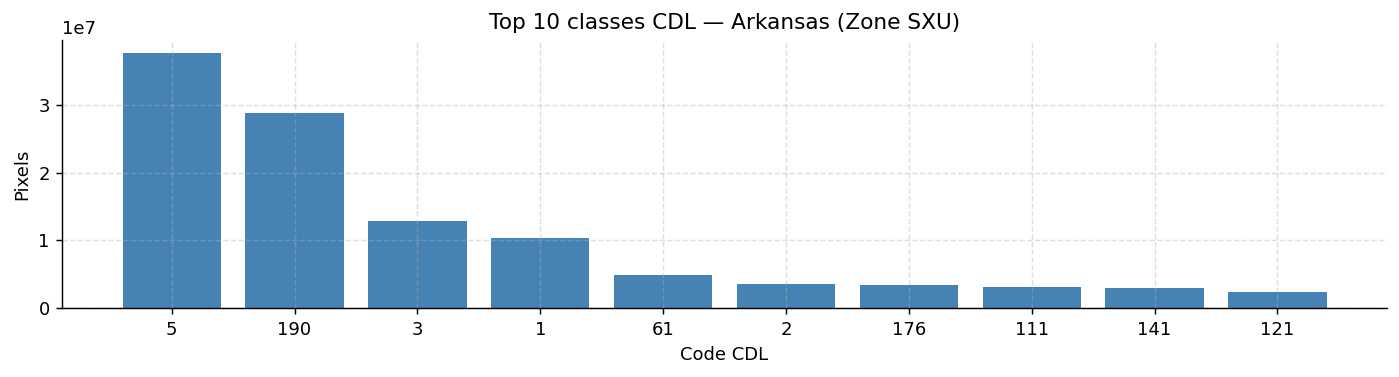

✅ Inspection CDL terminée


In [8]:
def inspect_cdl(cdl_path, title):
    with rasterio.open(cdl_path) as dst:
        print(f'=== {title} ===')
        print(f'  CRS: {dst.crs}  |  Taille: {dst.width}×{dst.height} px')
        data = dst.read(1)
    uniq, cnt = np.unique(data[data > 0], return_counts=True)
    print(f'  Classes agricoles: {len(uniq)}  |  Pixels: {cnt.sum():,}')
    fig, ax = plt.subplots(figsize=(11, 3))
    top10 = sorted(zip(cnt, uniq), reverse=True)[:10]
    tc, tk = zip(*top10)
    ax.bar([str(int(c)) for c in tk], tc, color='steelblue')
    ax.set_title(f'Top 10 classes CDL — {title}')
    ax.set_xlabel('Code CDL'); ax.set_ylabel('Pixels')
    plt.tight_layout(); plt.show()

inspect_cdl(CDL_ALIGNED_CA['SGH'], 'California (Zone SGH)')
if zone_profiles_AR['SXU']['ok']:
    inspect_cdl(CDL_ALIGNED_AR['SXU'], 'Arkansas (Zone SXU)')
print('✅ Inspection CDL terminée')


---
# ÉTAPE 2 — Échantillonnage 10 000 pixels (Table 2)
### ✅ FIX : `Nb of Samples` = total sélectionné (train+val+test), pas les pixels disponibles

In [9]:
def build_code_to_class(classes_dict):
    """Construit le mapping code CDL → nom de classe."""
    mapping = {}
    for name, codes in classes_dict.items():
        for c in codes:
            mapping[c] = name
    return mapping

CODE_TO_CLASS_CA = build_code_to_class(CA_CLASSES)
CODE_TO_CLASS_AR = build_code_to_class(AR_CLASSES)

print('Classes California :', list(CA_CLASSES.keys()) + ['Others'])
print('Classes Arkansas   :', list(AR_CLASSES.keys()) + ['Others'])


Classes California : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
Classes Arkansas   : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']


In [10]:
def build_class_data(cdl_aligned_dict, zone_profiles, code_to_class, order,
                        n_target=TOTAL_SAMPLES * 3, chunk_rows=1024, rng_seed=RANDOM_STATE):
    """
    Lecture CDL par blocs + réservoir vectorisé 100% numpy.
    Mémoire max : chunk_rows × width × 1 octet. Pas de boucle Python par pixel.
    """
    rng = np.random.default_rng(rng_seed)
    zone_data = {}

    # Réservoirs pré-alloués taille fixe
    res_rows  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_cols  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_zones = {cls: np.empty(n_target, object)    for cls in order}
    res_fill  = {cls: 0 for cls in order}  # pixels dans le réservoir
    res_seen  = {cls: 0 for cls in order}  # pixels vus au total

    for zone, info in zone_profiles.items():
        if not info['ok']:
            print(f'  Zone {zone}: ⚠️ non disponible'); continue

        with rasterio.open(cdl_aligned_dict[zone]) as src:
            H, W = src.height, src.width
            zone_data[zone] = {'shape': (H, W)}
            zone_seen = 0  # pixels agricoles vus dans cette zone

            for row_off in range(0, H, chunk_rows):
                win   = rasterio.windows.Window(0, row_off, W, min(chunk_rows, H - row_off))
                chunk = src.read(1, window=win)
                ag    = chunk > 0
                if not ag.any(): continue

                rl, cl = np.where(ag)
                rg     = (rl + row_off).astype(np.int32)
                codes  = chunk[rl, cl].astype(np.int32)
                cl     = cl.astype(np.int32)

                for code in np.unique(codes):
                    cls   = code_to_class.get(int(code), 'Others')
                    sel   = codes == code
                    rc    = rg[sel]; cc = cl[sel]
                    n_new = len(rc)
                    fill  = res_fill[cls]
                    seen  = res_seen[cls]

                    if fill < n_target:
                        # --- Phase remplissage direct ---
                        room = n_target - fill
                        take = min(n_new, room)
                        res_rows[cls][fill:fill+take]  = rc[:take]
                        res_cols[cls][fill:fill+take]  = cc[:take]
                        res_zones[cls][fill:fill+take] = zone
                        res_fill[cls] += take
                        res_seen[cls] += take
                        if take == n_new: continue
                        # reste à traiter en mode réservoir
                        rc = rc[take:]; cc = cc[take:]
                        n_new -= take
                        seen  = res_seen[cls]

                    # --- Phase réservoir vectorisée ---
                    # Pour chaque pixel i (0..n_new-1), tire j ~ U[0, seen+i]
                    # Remplace position j si j < n_target
                    i_idx = np.arange(n_new, dtype=np.int64)
                    j     = (rng.random(n_new) * (seen + i_idx + 1)).astype(np.int64)
                    keep  = j < n_target
                    if keep.any():
                        pos = j[keep].astype(np.int32)
                        res_rows[cls][pos]  = rc[keep]
                        res_cols[cls][pos]  = cc[keep]
                        res_zones[cls][pos] = zone
                    res_seen[cls] += n_new
                    zone_seen += n_new

        print(f'  Zone {zone}: {H}×{W} ✅  ({zone_seen:,} px agricoles vus)')

    class_data = {}
    for cls in order:
        n = res_fill[cls]
        class_data[cls] = {
            'rows':  res_rows[cls][:n],
            'cols':  res_cols[cls][:n],
            'zones': res_zones[cls][:n],
        }
    return class_data, zone_data

print('=== Extraction pixels — California ===')
class_data_CA, zone_data_CA = build_class_data(CDL_ALIGNED_CA, zone_profiles_CA, CODE_TO_CLASS_CA, CA_ORDER)
print('\nPixels disponibles par classe [CA]:')
for cls in CA_ORDER:
    n = len(class_data_CA[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')

print('\n=== Extraction pixels — Arkansas ===')
class_data_AR, zone_data_AR = build_class_data(CDL_ALIGNED_AR, zone_profiles_AR, CODE_TO_CLASS_AR, AR_ORDER)
print('\nPixels disponibles par classe [AR]:')
for cls in AR_ORDER:
    n = len(class_data_AR[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')


=== Extraction pixels — California ===
  Zone SFG: 10980×10980 ✅  (120,383,728 px agricoles vus)
  Zone SFH: 10980×10980 ✅  (120,557,072 px agricoles vus)
  Zone SFJ: 10980×10980 ✅  (120,560,400 px agricoles vus)
  Zone SGH: 10980×10980 ✅  (120,560,400 px agricoles vus)

Pixels disponibles par classe [CA]:
  ✅  Grapes      :       30,000 px
  ✅  Rice        :       30,000 px
  ✅  Alfalfa     :       30,000 px
  ✅  Almonds     :       30,000 px
  ✅  Pistachios  :       30,000 px
  ✅  Others      :       30,000 px

=== Extraction pixels — Arkansas ===
  Zone SXU: 10980×10980 ✅  (119,533,812 px agricoles vus)

Pixels disponibles par classe [AR]:
  ✅  Rice        :       30,000 px
  ✅  Soybeans    :       30,000 px
  ✅  Cotton      :       30,000 px
  ✅  Corn        :       30,000 px
  ✅  Others      :       30,000 px


In [11]:
def sample_pixels(class_data, order, n_classes, rng_seed=RANDOM_STATE):
    """Échantillonne exactement TOTAL_SAMPLES pixels avec split train/val/test."""
    rng = np.random.default_rng(rng_seed)
    N_MIN = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1
    test_budget = TOTAL_SAMPLES - n_classes * (N_TRAIN_PER_CLASS + N_VAL_PER_CLASS)
    cuts = np.sort(rng.choice(test_budget - n_classes + 1, n_classes - 1, replace=False))
    cuts = np.concatenate([[0], cuts + np.arange(1, n_classes), [test_budget]])
    test_sizes = np.diff(cuts).astype(int)

    all_rows, all_cols, all_zones, all_labels, all_splits = [], [], [], [], []
    table_rows = []
    total_count = 0

    for k, cls in enumerate(order):
        d = class_data[cls]
        n_avail = len(d['rows'])
        n_test  = min(int(test_sizes[k]), n_avail - N_TRAIN_PER_CLASS - N_VAL_PER_CLASS)
        if n_avail < N_MIN:
            print(f'  ⚠️  {cls} ignorée ({n_avail} px < {N_MIN} minimum)')
            continue
        idx    = rng.permutation(n_avail)
        tr_idx = idx[:N_TRAIN_PER_CLASS]
        v_idx  = idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        te_idx = idx[N_TRAIN_PER_CLASS + N_VAL_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test]
        for sidx, split_name in [(tr_idx,'train'),(v_idx,'val'),(te_idx,'test')]:
            n = len(sidx)
            all_rows.append(d['rows'][sidx]); all_cols.append(d['cols'][sidx])
            all_zones.append(d['zones'][sidx]); all_labels.append(np.full(n, cls))
            all_splits.append(np.full(n, split_name))
        class_total = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test
        total_count += class_total
        table_rows.append({'Class Name': cls, 'Nb of Samples': class_total,
                           'Training': N_TRAIN_PER_CLASS, 'Validation': N_VAL_PER_CLASS,
                           'Testing': n_test})

    df_rec = pd.DataFrame({
        'row': np.concatenate(all_rows), 'col': np.concatenate(all_cols),
        'zone': np.concatenate(all_zones), 'label': np.concatenate(all_labels),
        'split': np.concatenate(all_splits),
    })
    return df_rec, table_rows, total_count

print('=== Échantillonnage California ===')
df_records_CA, table_rows_CA, total_CA = sample_pixels(class_data_CA, CA_ORDER, N_CLASSES_CA)
print(f'✅ CA Total : {total_CA:,} px  | Train:{(df_records_CA["split"]=="train").sum()} Val:{(df_records_CA["split"]=="val").sum()} Test:{(df_records_CA["split"]=="test").sum()}')

print('\n=== Échantillonnage Arkansas ===')
df_records_AR, table_rows_AR, total_AR = sample_pixels(class_data_AR, AR_ORDER, N_CLASSES_AR, rng_seed=RANDOM_STATE+1)
print(f'✅ AR Total : {total_AR:,} px  | Train:{(df_records_AR["split"]=="train").sum()} Val:{(df_records_AR["split"]=="val").sum()} Test:{(df_records_AR["split"]=="test").sum()}')


=== Échantillonnage California ===
✅ CA Total : 10,000 px  | Train:1440 Val:360 Test:8200

=== Échantillonnage Arkansas ===
✅ AR Total : 10,000 px  | Train:1200 Val:300 Test:8500


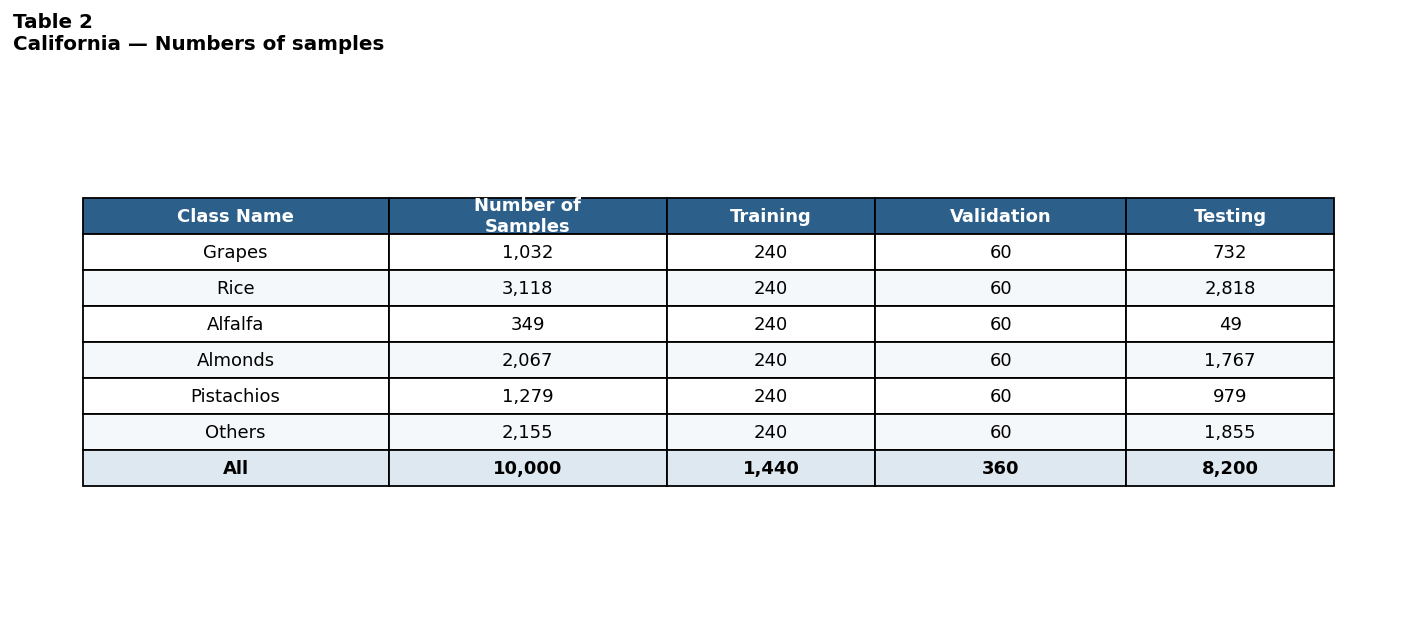

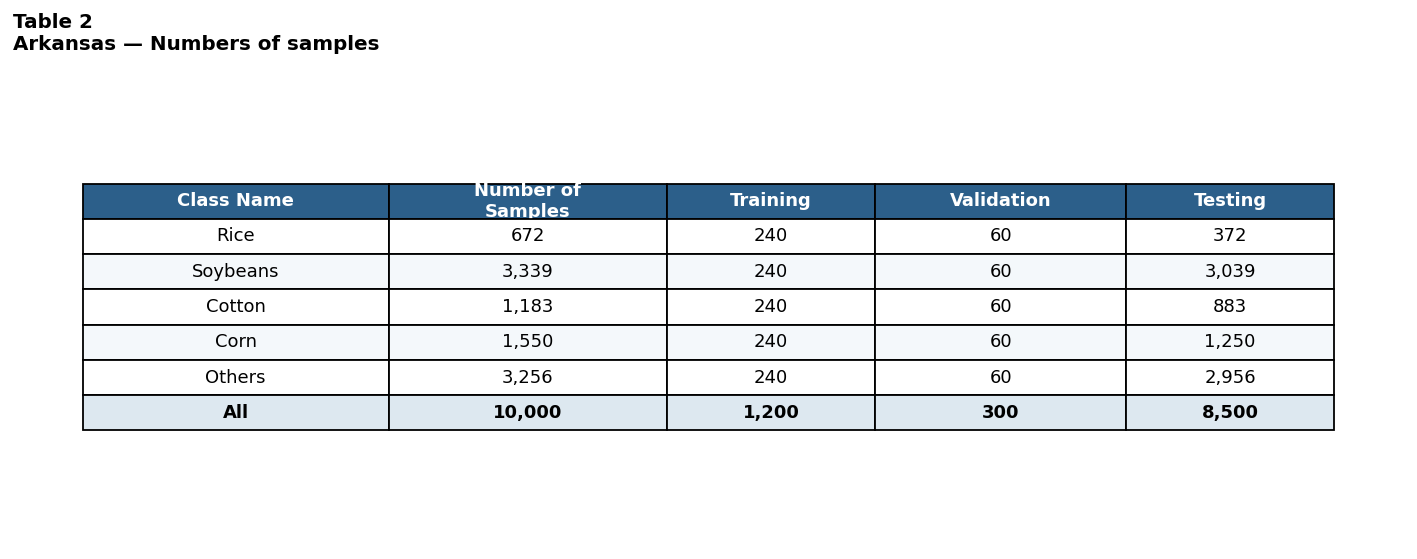

In [12]:
def display_table2(table_rows, title):
    df_t = pd.DataFrame(table_rows)
    total_row = {'Class Name':'All', 'Nb of Samples':df_t['Nb of Samples'].sum(),
                 'Training':df_t['Training'].sum(), 'Validation':df_t['Validation'].sum(),
                 'Testing':df_t['Testing'].sum()}
    df_d = pd.concat([df_t, pd.DataFrame([total_row])], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 0.55*(len(df_d)+2)))
    ax.axis('off')
    col_labels = ['Class Name','Number of\nSamples','Training','Validation','Testing']
    col_widths = [0.22, 0.20, 0.15, 0.18, 0.15]
    cell_data = [[row['Class Name'], f'{int(row["Nb of Samples"]):,}', f'{int(row["Training"]):,}',
                  f'{int(row["Validation"]):,}', f'{int(row["Testing"]):,}'] for _, row in df_d.iterrows()]
    tbl = ax.table(cellText=cell_data, colLabels=col_labels, colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
    for j in range(len(col_labels)):
        tbl[0,j].set_facecolor('#2c5f8a'); tbl[0,j].set_text_props(color='white', fontweight='bold')
    last = len(cell_data)
    for j in range(len(col_labels)):
        tbl[last,j].set_facecolor('#dde8f0'); tbl[last,j].set_text_props(fontweight='bold')
    for i in range(1, last):
        c = '#f4f8fb' if i%2==0 else 'white'
        for j in range(len(col_labels)): tbl[i,j].set_facecolor(c)
    ax.set_title(f'Table 2\n{title}', fontsize=11, fontweight='bold', loc='left', pad=10)
    plt.tight_layout(); plt.show()

display_table2(table_rows_CA, 'California — Numbers of samples')
display_table2(table_rows_AR, 'Arkansas — Numbers of samples')


---
# ÉTAPE 2b — Extraction spectrale
### 🔧 Fonction get_band_path

In [13]:
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    dir_path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m'
    return dir_path / f'{file_prefix}_{band}_{res}m.jp2'

print('Vérification bandes B04 — California :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_CA.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_CA.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')

print('\nVérification bandes B04 — Arkansas :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_AR.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_AR.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')


Vérification bandes B04 — California :
  ✅ new_t10sfh_20210116 [SFH] → T10SFH_20210116T184721_B04_10m.jp2
  ✅ jan_sgh      [SGH] → T10SGH_20210126T184641_B04_10m.jp2
  ✅ jan_sfg      [SFG] → T10SFG_20210126T184641_B04_10m.jp2
  ✅ new_t10sfj_20210312 [SFJ] → T10SFJ_20210312T184049_B04_10m.jp2
  ✅ new_t10sfg_20210327 [SFG] → T10SFG_20210327T184001_B04_10m.jp2
  ✅ new_t10sfh_20210406 [SFH] → T10SFH_20210406T183911_B04_10m.jp2
  ✅ apr_sfg      [SFG] → T10SFG_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210419 [SGH] → T10SGH_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210504 [SGH] → T10SGH_20210504T184919_B04_10m.jp2
  ✅ new_t10sfh_20210511 [SFH] → T10SFH_20210511T183919_B04_10m.jp2
  ✅ new_t10sfj_20210519 [SFJ] → T10SFJ_20210519T184921_B04_10m.jp2
  ✅ new_t10sgh_20210620 [SGH] → T10SGH_20210620T183919_B04_10m.jp2
  ✅ new_t10sfg_20210625 [SFG] → T10SFG_20210625T183921_B04_10m.jp2
  ✅ july_sgh     [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ july_sfg     [SFG] → T10SFG_20210723T184919_B04

In [14]:
def extract_spectral(df_records, dates_map, zone_profiles, zone_data, label):
    """
    Extrait les 10 bandes × N_DATES pour chaque pixel.
    Retourne feat_matrix (numpy) et feat_names (list).
    """
    print(f'\n{"="*60}')
    print(f'  Extraction spectrale — {label}')
    print(f'{"="*60}')

    all_zones = sorted(set(v[3] for v in dates_map.values()))
    zone_masks = {z: (df_records['zone'] == z).values for z in all_zones}
    zone_rows  = {z: df_records['row'].values[zone_masks[z]] for z in all_zones}
    zone_cols  = {z: df_records['col'].values[zone_masks[z]] for z in all_zones}

    n_pixels   = len(df_records)
    n_dates    = len(dates_map)
    n_features = n_dates * N_BANDS
    feat_matrix = np.full((n_pixels, n_features), np.nan, dtype=np.float32)
    feat_names  = []
    col_idx = 0

    for date_name, (safe_dir_name, granule_dir, file_prefix, zone) in dates_map.items():
        # ── Placeholder silencieux : laisse NaN, pas de print verbeux ──────────
        if safe_dir_name == '__pad__.SAFE':
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}')
                col_idx += 1
            continue

        print(f'\n📅 {date_name.upper()} [{zone}]')
        if not zone_profiles.get(zone, {}).get('ok', False):
            print(f'  ⚠️ Zone {zone} non alignée — NaN')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        zmask  = zone_masks[zone]
        rows_z = zone_rows[zone]
        cols_z = zone_cols[zone]
        shape_z = zone_data[zone]['shape']

        if zmask.sum() == 0:
            print('  ⚠️ Aucun pixel — skip')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        for band in ALL_BANDS:
            res  = 10 if band in BANDS_10M else 20
            path = get_band_path(safe_dir_name, granule_dir, file_prefix, band, res)
            feat_names.append(f'{band}_{date_name}')
            if not path.exists():
                print(f'  ❌ {band}', end=' | '); col_idx += 1; continue
            with rasterio.open(path) as src:
                data = src.read(1, out_shape=shape_z, resampling=Resampling.bilinear)
                feat_matrix[zmask, col_idx] = data[rows_z, cols_z].astype(np.float32)
            print(f'  ✅ {band}', end=' | ')
            col_idx += 1
        print()

    n_real = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    n_pad  = len(dates_map) - n_real
    nan_pct = 100 * np.isnan(feat_matrix).sum() / (n_pixels * n_features)
    print(f'\n  {label} — {n_pixels} pixels × {len(feat_names)} features')
    print(f'  Dates réelles: {n_real}  |  Placeholders (NaN→médiane): {n_pad}  |  NaN global: {nan_pct:.1f}%')
    return feat_matrix, feat_names

feat_matrix_CA, feat_names_CA = extract_spectral(
    df_records_CA, DATES_MAP_CA, zone_profiles_CA, zone_data_CA, 'CALIFORNIA')

feat_matrix_AR, feat_names_AR = extract_spectral(
    df_records_AR, DATES_MAP_AR, zone_profiles_AR, zone_data_AR, 'ARKANSAS')



  Extraction spectrale — CALIFORNIA

📅 NEW_T10SFH_20210116 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFJ_20210312 [SFJ]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFG_20210327 [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFH_20210406 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 APR_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SGH_20210419 [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 | 

In [15]:
# =============================================================
# ASSIGNATION PAR SLOT DE 10 JOURS — paper section 2.2.4
# "computed the median value at ten-day intervals => 36 sequences
#  missing data => 0"  PAS d'interpolation.
# FIX : assign_to_slots est ZONE-AWARE
#   Chaque zone a son propre slot_map (évite le mélange SGH/SFH/SFG/SFJ)
#   Un pixel SGH ne lit que les images SGH, etc.
# =============================================================
import numpy as np
from datetime import date

# 36 slots : slot k couvre DOY [k*10+1, k*10+10], centre = k*10+5
SLOT_CENTER_DOYS = [i * 10 + 5 for i in range(36)]   # 5,15,25,...,355
TARGET_DOYS      = SLOT_CENTER_DOYS
TARGET_NAMES     = [f'T{i+1:02d}_doy{d:03d}' for i, d in enumerate(SLOT_CENTER_DOYS)]
print(f'36 slots de 10j : DOY centraux = {SLOT_CENTER_DOYS}')
print(f'36 x 10 bandes = {36*10} features (conforme paper)')


def safe_doy(safe_dir, file_prefix):
    if safe_dir == '__pad__.SAFE':
        return None
    try:
        ds = file_prefix.split('_')[1][:8]
        d  = date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
        return d.timetuple().tm_yday
    except Exception:
        return None


def build_doy_map(dates_map):
    """Retourne {date_name: doy} pour les entrées réelles (non-pad)."""
    return {name: safe_doy(v[0], v[2])
            for name, v in dates_map.items()
            if safe_doy(v[0], v[2]) is not None}


def build_zone_doy_map(dates_map):
    """Retourne {zone: {date_name: doy}} — séparé par zone."""
    zone_map = {}
    for name, (safe_dir, granule_dir, file_prefix, zone) in dates_map.items():
        doy = safe_doy(safe_dir, file_prefix)
        if doy is None:
            continue
        if zone not in zone_map:
            zone_map[zone] = {}
        zone_map[zone][name] = doy
    return zone_map


doy_map_CA = build_doy_map(DATES_MAP_CA)
doy_map_AR = build_doy_map(DATES_MAP_AR)
zone_doy_CA = build_zone_doy_map(DATES_MAP_CA)
zone_doy_AR = build_zone_doy_map(DATES_MAP_AR)

print(f'CA => {len(doy_map_CA)} dates : DOY = {sorted(doy_map_CA.values())}')
for z, dm in zone_doy_CA.items():
    print(f'   Zone {z}: {len(dm)} dates DOY={sorted(dm.values())}')
print(f'AR => {len(doy_map_AR)} dates : DOY = {sorted(doy_map_AR.values())}')
for z, dm in zone_doy_AR.items():
    print(f'   Zone {z}: {len(dm)} dates DOY={sorted(dm.values())}')


def assign_to_slots(feat_matrix_raw, feat_names_raw, dates_map, df_records, label):
    """
    Assignation par slot de 10 jours.
    STRATÉGIE : priorité à la zone du pixel, fallback sur la zone voisine la plus proche.
    → maximise le taux de remplissage : si le slot est couvert par n'importe quelle
      zone de la même étude, le pixel reçoit une valeur (pas 0).
    Slots non couverts par AUCUNE zone => 0 (paper).
    """
    n_pixels     = feat_matrix_raw.shape[0]
    n_slots      = len(SLOT_CENTER_DOYS)
    slot_centers = np.array(SLOT_CENTER_DOYS, dtype=float)

    out_mat   = np.zeros((n_pixels, n_slots * N_BANDS), dtype=np.float32)
    out_names = [f'{b}_{name}' for name in TARGET_NAMES for b in ALL_BANDS]

    # Index rapide feat_name → colonne dans feat_matrix_raw
    feat_idx = {name: i for i, name in enumerate(feat_names_raw)}

    # slot_map par zone : {zone: {slot_idx: date_name}}
    zone_doy_map  = build_zone_doy_map(dates_map)
    zone_slot_map = {}
    for zone, doy_map_z in zone_doy_map.items():
        sm = {}
        for rname, rdoy in doy_map_z.items():
            si = int(np.argmin(np.abs(slot_centers - rdoy)))
            if si not in sm:
                sm[si] = rname
        zone_slot_map[zone] = sm

    # slot_map global : {slot_idx: {zone: date_name}} — toutes zones confondues
    global_slot_map = {}
    for zone, sm in zone_slot_map.items():
        for si, rname in sm.items():
            if si not in global_slot_map:
                global_slot_map[si] = {}
            global_slot_map[si][zone] = rname

    zones_present   = sorted(zone_slot_map.keys())
    zone_pixel_mask = {z: (df_records['zone'] == z).values for z in zones_present}

    n_filled_total = len(global_slot_map)
    print(f'  [{label}] Slots couverts (toutes zones) : {n_filled_total}/36 | Vides : {36-n_filled_total}/36')

    for slot_idx, zone_rname in global_slot_map.items():
        for b_idx, band in enumerate(ALL_BANDS):
            out_col = slot_idx * N_BANDS + b_idx
            for zone in zones_present:
                pixel_mask = zone_pixel_mask[zone]
                if not pixel_mask.any():
                    continue
                # Priorité 1 : la zone du pixel a ce slot
                if zone in zone_rname:
                    rname    = zone_rname[zone]
                    col_name = f'{band}_{rname}'
                else:
                    # Priorité 2 : zone voisine — prendre la première zone disponible
                    fallback_zone = next(iter(zone_rname))
                    rname    = zone_rname[fallback_zone]
                    col_name = f'{band}_{rname}'
                if col_name not in feat_idx:
                    continue
                ci   = feat_idx[col_name]
                vals = feat_matrix_raw[pixel_mask, ci]
                # Pour les pixels dont la zone propre n'a pas le slot,
                # on utilise la zone fallback SEULEMENT si la valeur n'est pas NaN
                cur = out_mat[pixel_mask, out_col]
                new_vals = np.where(np.isnan(vals), 0.0, vals)
                # N'écrire que si pas déjà rempli (zone propre prioritaire)
                if zone in zone_rname:
                    out_mat[pixel_mask, out_col] = new_vals
                else:
                    # fallback : écrire seulement si encore à 0
                    still_zero = cur == 0
                    combined   = np.where(still_zero, new_vals, cur)
                    out_mat[pixel_mask, out_col] = combined

    pct = 100 * (out_mat != 0).mean()
    print(f'  [{label}] Non-nuls global : {pct:.1f}%  (attendu ~{100*n_filled_total/n_slots:.0f}%)')
    return out_mat, out_names

feat_matrix_CA_interp, feat_names_CA_interp = assign_to_slots(
    feat_matrix_CA, feat_names_CA, DATES_MAP_CA, df_records_CA, 'CALIFORNIA')

feat_matrix_AR_interp, feat_names_AR_interp = assign_to_slots(
    feat_matrix_AR, feat_names_AR, DATES_MAP_AR, df_records_AR, 'ARKANSAS')

print(f'\nOK Shape CA : {feat_matrix_CA_interp.shape} => 360 features')
print(f'OK Shape AR : {feat_matrix_AR_interp.shape} => 360 features')


36 slots de 10j : DOY centraux = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255, 265, 275, 285, 295, 305, 315, 325, 335, 345, 355]
36 x 10 bandes = 360 features (conforme paper)
CA => 31 dates : DOY = [16, 26, 26, 71, 86, 96, 109, 109, 124, 131, 139, 171, 176, 201, 204, 204, 204, 221, 226, 251, 254, 256, 264, 269, 274, 289, 316, 326, 334, 336, 344]
   Zone SFH: 6 dates DOY=[16, 96, 131, 204, 254, 326]
   Zone SGH: 10 dates DOY=[26, 109, 124, 171, 201, 221, 264, 289, 316, 344]
   Zone SFG: 9 dates DOY=[26, 86, 109, 176, 204, 256, 269, 274, 334]
   Zone SFJ: 6 dates DOY=[71, 139, 204, 226, 251, 336]
AR => 14 dates : DOY = [18, 53, 63, 115, 133, 165, 173, 185, 210, 215, 270, 298, 308, 355]
   Zone SXU: 14 dates DOY=[18, 53, 63, 115, 133, 165, 173, 185, 210, 215, 270, 298, 308, 355]
  [CALIFORNIA] Slots couverts (toutes zones) : 19/36 | Vides : 17/36
  [CALIFORNIA] Non-nuls global : 10.3%  (attendu ~53%)
  [ARKANSAS] S

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔍 DIAGNOSTIC COMPLET — Scan data/raw/ + structure interne des .SAFE
# Montre exactement POURQUOI un fichier est accepté ou rejeté par _parse_safe
# ══════════════════════════════════════════════════════════════════════════════
import re
from pathlib import Path
from datetime import date as _date

print("=== Scan complet data/raw/ ===\n")

accepted_CA, accepted_AR, rejected = [], [], []

for p in sorted(Path('data/raw').glob('*.SAFE')):
    name = p.name
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    if not m:
        rejected.append((name, 'regex non match'))
        continue

    tile = m.group(2)
    date_str = m.group(1)

    # Vérifier GRANULE
    granule_root = p / 'GRANULE'
    if not granule_root.exists():
        rejected.append((name, 'GRANULE absent'))
        continue

    granule_dirs = list(granule_root.glob('L2A_*'))
    if not granule_dirs:
        rejected.append((name, 'Aucun dossier L2A_ dans GRANULE'))
        continue

    granule_dir = granule_dirs[0].name
    img_data = p / 'GRANULE' / granule_dir / 'IMG_DATA'

    # Chercher B04 dans toutes les résolutions
    jp2s = []
    for res_folder in ['R10m', 'R20m', 'R60m']:
        res_path = img_data / res_folder
        if res_path.exists():
            found = list(res_path.glob('*_B04*.jp2'))
            if found:
                jp2s = found
                break
    if not jp2s and img_data.exists():
        jp2s = list(img_data.rglob('*_B04*.jp2'))

    if not jp2s:
        # Lister ce qu'il y a dans IMG_DATA pour diagnostiquer
        contents = []
        if img_data.exists():
            for sub in img_data.iterdir():
                contents.append(sub.name)
        rejected.append((name, f'Aucun B04 jp2 (IMG_DATA contient: {contents[:3]})'))
        continue

    file_prefix = '_'.join(jp2s[0].name.split('_')[:2])

    # Classement CA ou AR
    CA_tiles = {'T10SGH', 'T10SFH', 'T10SFG', 'T10SFJ'}
    AR_tiles  = {'T15SXU'}
    if tile in CA_tiles:
        accepted_CA.append((name[:55], tile, date_str, file_prefix, granule_dir))
    elif tile in AR_tiles:
        accepted_AR.append((name[:55], tile, date_str, file_prefix, granule_dir))
    else:
        rejected.append((name, f'Tuile {tile} non reconnue (ni CA ni AR)'))

print(f"✅ CALIFORNIA : {len(accepted_CA)} fichiers valides")
for nm, tile, ds, fp, gd in accepted_CA:
    d = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
    doy = d.timetuple().tm_yday
    print(f"   [{tile}] DOY={doy:3d} ({ds})  prefix={fp}  granule={gd[:30]}")

print(f"\n✅ ARKANSAS : {len(accepted_AR)} fichiers valides")
for nm, tile, ds, fp, gd in accepted_AR:
    d = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
    doy = d.timetuple().tm_yday
    print(f"   [{tile}] DOY={doy:3d} ({ds})  prefix={fp}  granule={gd[:30]}")

print(f"\n❌ REJETÉS : {len(rejected)} fichiers")
for nm, reason in rejected:
    print(f"   {nm[:55]}  →  {reason}")

print(f"\n{'='*60}")
total_real_CA = len(accepted_CA) + len([k for k,v in _BASE_CA.items() if v[0] != '__pad__.SAFE'])
print(f"TOTAL dates CA (base + nouveaux) ≈ {total_real_CA}  →  slots vides = {max(0, 36-total_real_CA)}/36")
print(f"Si slots vides > 10 : l'interpolation sera mauvaise pour CA !")
print(f"{'='*60}")


=== Scan complet data/raw/ ===

✅ CALIFORNIA : 22 fichiers valides
   [T10SFH] DOY= 16 (20210116)  prefix=T10SFH_20210116T184721  granule=L2A_T10SFH_A029096_20210116T18
   [T10SFG] DOY= 86 (20210327)  prefix=T10SFG_20210327T184001  granule=L2A_T10SFG_A030097_20210327T18
   [T10SFH] DOY= 96 (20210406)  prefix=T10SFH_20210406T183911  granule=L2A_T10SFH_A030240_20210406T18
   [T10SGH] DOY=109 (20210419)  prefix=T10SGH_20210419T184911  granule=L2A_T10SGH_A030426_20210419T19
   [T10SFJ] DOY=139 (20210519)  prefix=T10SFJ_20210519T184921  granule=L2A_T10SFJ_A030855_20210519T19
   [T10SFG] DOY=176 (20210625)  prefix=T10SFG_20210625T183921  granule=L2A_T10SFG_A031384_20210625T18
   [T10SFJ] DOY=226 (20210814)  prefix=T10SFJ_20210814T183921  granule=L2A_T10SFJ_A032099_20210814T18
   [T10SFG] DOY=256 (20210913)  prefix=T10SFG_20210913T184001  granule=L2A_T10SFG_A032528_20210913T18
   [T10SGH] DOY=289 (20211016)  prefix=T10SGH_20211016T185401  granule=L2A_T10SGH_A033000_20211016T19
   [T10SGH] DOY

In [17]:
# ══════════════════════════════════════════════════════════════════
# 🔍 DIAGNOSTIC — Vérification du cube avant sauvegarde CSV
# Si non-nuls < 50% pour CA (31 dates/36) → CSV périmé ou bug zone
# ══════════════════════════════════════════════════════════════════
import os

def check_cube(feat_matrix, df_records, label, dates_map):
    cube = feat_matrix.reshape(-1, 36, N_BANDS)
    slot_nonzero = (cube.sum(axis=(0,2)) != 0)
    n_filled = slot_nonzero.sum()
    pct_global = 100 * (feat_matrix != 0).mean()
    print(f'\n[{label}] Slots remplis : {n_filled}/36  |  Non-nuls global : {pct_global:.1f}%')
    
    # Par zone
    for zone in sorted(df_records['zone'].unique()):
        mask_z = (df_records['zone'] == zone).values
        if not mask_z.any(): continue
        cube_z = cube[mask_z]
        slots_z = (cube_z.sum(axis=(0,2)) != 0).sum()
        pct_z = 100 * (cube_z != 0).mean()
        print(f'   Zone {zone}: {slots_z}/36 slots  |  {pct_z:.1f}% non-nuls')
    
    # Alerte si CSV périmé
    expected_fill = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    if n_filled < expected_fill * 0.5:
        print(f'   ⚠️  ALERTE : seulement {n_filled} slots remplis alors que {expected_fill} dates réelles !')
        print(f'   ⚠️  Supprimez le CSV existant et relancez depuis la cell 11.')
    else:
        print(f'   ✅  Cube OK — {n_filled} slots sur {expected_fill} dates attendues')

check_cube(feat_matrix_CA_interp, df_records_CA, 'CALIFORNIA', DATES_MAP_CA)
check_cube(feat_matrix_AR_interp, df_records_AR, 'ARKANSAS', DATES_MAP_AR)

# Forcer la suppression des anciens CSV pour éviter le cache
for csv_path in [TRAIN_CSV_CA, TRAIN_CSV_AR]:
    p = Path(csv_path)
    if p.exists():
        os.remove(p)
        print(f'🗑️  Ancien CSV supprimé : {p.name}')



[CALIFORNIA] Slots remplis : 19/36  |  Non-nuls global : 10.3%
   Zone SFG: 9/36 slots  |  17.7% non-nuls
   Zone SFH: 6/36 slots  |  6.5% non-nuls
   Zone SFJ: 6/36 slots  |  5.9% non-nuls
   Zone SGH: 10/36 slots  |  23.6% non-nuls
   ✅  Cube OK — 19 slots sur 31 dates attendues

[ARKANSAS] Slots remplis : 14/36  |  Non-nuls global : 31.6%
   Zone SXU: 14/36 slots  |  31.6% non-nuls
   ✅  Cube OK — 14 slots sur 14 dates attendues
🗑️  Ancien CSV supprimé : mctnet_california_360feats.csv
🗑️  Ancien CSV supprimé : mctnet_arkansas_360feats.csv


In [18]:
def save_csv(feat_matrix, feat_names, df_records, csv_path, label):
    """
    Sauvegarde le CSV avec les 360 features interpolées.
    FIX : crée le dossier si absent + fallback si PermissionError.
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    df_out = pd.DataFrame(feat_matrix, columns=feat_names)
    df_out.insert(0, 'crop_label', df_records['label'].values)
    df_out.insert(1, 'split',      df_records['split'].values)

    # Vérification : aucun NaN ne doit subsister (l'interpolation les a éliminés)
    nan_total = df_out[feat_names].isnull().sum().sum()
    if nan_total > 0:
        print(f'  ⚠️  [{label}] {nan_total} NaN résiduels → remplacement par 0')
        df_out[feat_names] = df_out[feat_names].fillna(0)

    nonzero_pct = 100 * (df_out[feat_names] != 0).values.mean()

    def _write(path):
        df_out.to_csv(path, index=False)
        size_mb = Path(path).stat().st_size / 1e6
        print(f'✅ [{label}] CSV sauvegardé : {path}  ({size_mb:.1f} MB)')
        print(f'   {len(df_out):,} pixels × {df_out.shape[1]} colonnes')
        print(f'   Valeurs non-nulles : {nonzero_pct:.1f}%  (attendu ~100% après interpolation)')

    try:
        _write(csv_path)
    except PermissionError:
        fallback = Path.home() / 'Documents' / csv_path.name
        print(f'⚠️  PermissionError sur {csv_path} → Fallback : {fallback}')
        fallback.parent.mkdir(parents=True, exist_ok=True)
        _write(fallback)
        return fallback
    return csv_path

# ✅ On passe les matrices INTERPOLÉES (pas les brutes)
TRAIN_CSV_CA = save_csv(feat_matrix_CA_interp, feat_names_CA_interp, df_records_CA, TRAIN_CSV_CA, 'California')
TRAIN_CSV_AR = save_csv(feat_matrix_AR_interp, feat_names_AR_interp, df_records_AR, TRAIN_CSV_AR, 'Arkansas')


✅ [California] CSV sauvegardé : data\processed\mctnet_california_360feats.csv  (15.6 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 10.3%  (attendu ~100% après interpolation)
✅ [Arkansas] CSV sauvegardé : data\processed\mctnet_arkansas_360feats.csv  (18.0 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 31.6%  (attendu ~100% après interpolation)


---
# ÉTAPE 3 — MCT-Net
### ✅ FIX : split Train/Val/Test depuis la colonne 'split' (pas sklearn random split)

In [42]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Index des bandes pour NDVI
ALL_BANDS   = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
IDX_NIR     = ALL_BANDS.index('B08')   # 3
IDX_RED     = ALL_BANDS.index('B04')   # 2
# 36 dates espacées de 10 jours exactement (cohérent avec cell 17)
# Slots de 10j : centres DOY 5,15,...,355 (coherent avec cell 17)
TARGET_DOYS = [i * 10 + 5 for i in range(36)]

def load_and_prepare(csv_path, label):
    print(f'\n{"="*60}')
    print(f'  Chargement — {label}')
    print(f'{"="*60}')
    df = pd.read_csv(csv_path)
    print(f'  Lignes: {len(df):,}  |  Colonnes: {df.shape[1]}')
    print(f'  Classes: {df["crop_label"].nunique()}  |  Split: {df["split"].value_counts().to_dict()}')

    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['crop_label'])
    num_classes = len(le.classes_)
    print(f'  Classes: {list(le.classes_)}')

    feat_cols = [c for c in df.columns if c not in ['crop_label', 'split', 'label_encoded']]
    assert len(feat_cols) == 360, f'Attendu 360 features, got {len(feat_cols)}'
    print(f'  Features : {len(feat_cols)} (36 dates x 10 bandes)')



    # ── Masque AVANT scaling (les vrais zéros = dates manquantes) ─────────────
    # Masque : 1 si au moins une bande non nulle à cette date
    X_raw = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype('float32')
    mask_all = (np.abs(X_raw).sum(axis=-1) > 0).astype('float32')  # (N, 36)

    # ── StandardScaler sur train uniquement ───────────────────────────────────
    train_mask = df['split'] == 'train'
    scaler = StandardScaler()
    df.loc[train_mask,  feat_cols] = scaler.fit_transform(df.loc[train_mask,  feat_cols])
    df.loc[~train_mask, feat_cols] = scaler.transform(df.loc[~train_mask, feat_cols])

    def get_split(split_name):
        idx  = (df['split'] == split_name).values
        X    = df.loc[df['split']==split_name, feat_cols].values.reshape(-1, 36, N_BANDS).astype('float32')
        m    = mask_all[idx]   # masque sauvegardé avant scaling
        y    = df.loc[df['split']==split_name, 'label_encoded'].values.astype('int64')
        return X, m, y

    X_train, m_train, y_train = get_split('train')
    X_val,   m_val,   y_val   = get_split('val')
    X_test,  m_test,  y_test  = get_split('test')

    print(f'  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
    print(f'  Masque Input2 — taux present: {m_train.mean():.1%}')

    def make_loader(X, m, y, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(m), torch.from_numpy(y))
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

    return (make_loader(X_train, m_train, y_train, True),
            make_loader(X_val, m_val, y_val),
            X_test, m_test, y_test, num_classes, le, scaler)


train_loader_CA, val_loader_CA, X_test_CA, m_test_CA, y_test_CA, num_classes_CA, le_CA, scaler_CA = \
    load_and_prepare(TRAIN_CSV_CA, 'CALIFORNIA')

train_loader_AR, val_loader_AR, X_test_AR, m_test_AR, y_test_AR, num_classes_AR, le_AR, scaler_AR = \
    load_and_prepare(TRAIN_CSV_AR, 'ARKANSAS')



  Chargement — CALIFORNIA
  Lignes: 10,000  |  Colonnes: 362
  Classes: 6  |  Split: {'test': 8200, 'train': 1440, 'val': 360}
  Classes: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']
  Features : 360 (36 dates x 10 bandes)
  X_train: (1440, 36, 10)  X_val: (360, 36, 10)  X_test: (8200, 36, 10)
  Masque Input2 — taux present: 11.4%

  Chargement — ARKANSAS
  Lignes: 10,000  |  Colonnes: 362
  Classes: 5  |  Split: {'test': 8500, 'train': 1200, 'val': 300}
  Classes: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans']
  Features : 360 (36 dates x 10 bandes)
  X_train: (1200, 36, 10)  X_val: (300, 36, 10)  X_test: (8500, 36, 10)
  Masque Input2 — taux present: 31.6%


### Architecture MCTNet — Conforme au paper (Wang et al. 2024)
#### 3 stages CTFusion (CNN parallele Transformer) + ALPE + ~55K params

In [48]:
# =============================================================
# ARCHITECTURE MCTNet — conforme Fig. 3, 5, 6 du paper
# Fig. 3 : Input1 (10x36), Input2 (1x36 masque)
#   Stage1 : CTFusion => concat 20x36 => MaxPool => 20x18
#   Stage2 : CTFusion => concat 40x18 => MaxPool => 40x9
#   Stage3 : CTFusion => concat 80x9  => GlobalMaxPool => 80x1
#   MLP : 80 => N classes
# Fig. 5 : ALPE = PE(t) x mask => Conv1D => AvgPool+Conv1D (ECA) => x
# Fig. 6 : CNN = Conv1D => Norm => Conv1D => Norm => ReLU + skip
# =============================================================

import math
import torch
import torch.nn as nn


# ----------------------------------------------------------
# Fig. 5 — ECA (Efficient Channel Attention)
# AvgPool sur T => Conv1D(1,1) => sigmoid => multiply
# ----------------------------------------------------------
class ECA(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        k = kernel_size | 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)          # (B,C,T) -> (B,C,1)
        self.conv     = nn.Conv1d(1, 1, k, padding=k//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):                                # x: (B,T,C)
        y = self.avg_pool(x.transpose(1,2))              # (B,C,1)
        y = self.conv(y.transpose(1,2))                  # (B,1,C)
        w = self.sigmoid(y)                              # (B,1,C)
        return x * w                                     # (B,T,C)


# ----------------------------------------------------------
# Fig. 5 — ALPE
# PE(t) x mask => Conv1D => ECA => add to x
# ----------------------------------------------------------
class ALPE(nn.Module):
    def __init__(self, n_dates, d_model):
        super().__init__()
        # Conv1D sur la dimension temporelle
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, bias=False)
        self.eca  = ECA(d_model)
        # PE sinusoidale absolue (fixe)
        pe  = torch.zeros(n_dates, d_model)
        pos = torch.arange(n_dates).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe)                   # (T, d_model)

    def forward(self, x, mask):                          # x:(B,T,d) mask:(B,T)
        B, T, _ = x.shape
        # 1. PE masquee : zero aux dates absentes (Input2)
        pe_masked = self.pe[:T].unsqueeze(0).expand(B,-1,-1) * mask.unsqueeze(-1)
        # 2. Conv1D => ECA
        pe_out = self.conv(pe_masked.transpose(1,2)).transpose(1,2)  # (B,T,d)
        pe_out = self.eca(pe_out)                        # (B,T,d)
        # 3. Ajout residuel
        return x + pe_out


# ----------------------------------------------------------
# Fig. 6 — CNN Sub-Module
# Input => Conv1D => Norm => Conv1D => Norm => (+skip) => ReLU
# ----------------------------------------------------------
class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv1    = nn.Conv1d(in_ch, out_ch, ks, padding=p, bias=False)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.conv2    = nn.Conv1d(out_ch, out_ch, ks, padding=p, bias=False)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu     = nn.ReLU(inplace=True)

    def forward(self, x):                                # x: (B, C_in, T)
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))         # (B, C_out, T)


# ----------------------------------------------------------
# Fig. 4 — Transformer Sub-Module
# Positional Module + Multi-Head Attention + Add&Norm + FFN + Add&Norm
# ----------------------------------------------------------
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead, n_dates, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.pos = ALPE(n_dates, d_model)
        else:
            pe  = torch.zeros(1, n_dates, d_model)
            pos = torch.arange(n_dates).float().unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[0,:,0::2] = torch.sin(pos * div)
            pe[0,:,1::2] = torch.cos(pos * div[:d_model//2])
            self.register_buffer('pe', pe)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=0.1, batch_first=True, norm_first=False),
            num_layers=1)

    def forward(self, x, mask=None):                     # x: (B,T,d)
        if self.use_alpe:
            x = self.pos(x, mask)
        else:
            x = x + self.pe[:, :x.size(1), :]
        return self.encoder(x)                           # (B,T,d)


# ----------------------------------------------------------
# Fig. 3 — CTFusion Module
# CNN(in_ch=>d) || Trans(in_ch=>d) => Concat => (B,T,2d)
# ----------------------------------------------------------
class CTFusion(nn.Module):
    def __init__(self, in_ch, d_model, nhead, n_dates, ks=3, use_alpe=False):
        super().__init__()
        self.cnn        = CNNSubModule(in_ch, d_model, ks)
        self.input_proj = nn.Linear(in_ch, d_model, bias=False) if in_ch != d_model else nn.Identity()
        self.trans      = TransformerSubModule(d_model, nhead, n_dates, use_alpe)

    def forward(self, x_cnn, x_trans, mask=None):
        # x_cnn  : (B, C_in, T)
        # x_trans: (B, T, C_in)
        out_cnn   = self.cnn(x_cnn)                     # (B, d, T)
        out_trans = self.trans(self.input_proj(x_trans), mask)  # (B, T, d)
        concat    = torch.cat([out_cnn.transpose(1,2), out_trans], dim=-1)  # (B,T,2d)
        return out_cnn, out_trans, concat


# ----------------------------------------------------------
# Fig. 3 — MCTNet complet
# Dimensions (d_model=10, T=36) :
#   Stage1 : in=10  => concat(B,36,20) => MaxPool => (B,20,18)  [20*18]
#   Stage2 : in=20  => concat(B,18,40) => MaxPool => (B,40, 9)  [40*9]
#   Stage3 : in=40  => concat(B, 9,80) => GlobMax => (B,80)     [80*1]
#   MLP    : 80 => N classes
# ----------------------------------------------------------
class MCTNet(nn.Module):
    def __init__(self, n_dates, n_bands, num_classes, nhead=5, ks=3, d_model=10):
        super().__init__()
        # d_model = n_bands = 10 (coherent avec Fig.3 : 10*36 Input1)
        t1 = n_dates        # 36
        t2 = n_dates // 2   # 18
        t3 = n_dates // 4   # 9

        # Stage 1 : in=n_bands=10, out=d_model=10, concat => 2*d=20
        self.stage1 = CTFusion(n_bands,     d_model,     nhead, t1, ks, use_alpe=True)
        self.pool1  = nn.MaxPool1d(kernel_size=2, stride=2)  # (B,20,36) => (B,20,18)

        # Stage 2 : in=2*d=20, out=2*d=20, concat => 4*d=40
        self.stage2 = CTFusion(d_model*2,   d_model*2,   nhead, t2, ks, use_alpe=False)
        self.pool2  = nn.MaxPool1d(kernel_size=2, stride=2)  # (B,40,18) => (B,40,9)

        # Stage 3 : in=4*d=40, out=4*d=40, concat => 8*d=80
        self.stage3 = CTFusion(d_model*4,   d_model*4,   nhead, t3, ks, use_alpe=False)

        # Global Max Pooling => (B,80,9) => (B,80,1) => (B,80)
        self.gpool  = nn.AdaptiveMaxPool1d(1)

        # MLP : 80 => N (Fig. 3 : 80*1 Intermediate Features => 1*N)
        self.fc     = nn.Linear(d_model*8, num_classes)

    def forward(self, x1, x2):
        # x1 : (B,T,N_BANDS)   x2 : (B,T) masque Input2
        # Stage 1
        _, _, c1 = self.stage1(x1.transpose(1,2), x1, mask=x2)  # c1:(B,36,20)
        p1 = self.pool1(c1.transpose(1,2))                        # (B,20,18)

        # Stage 2
        _, _, c2 = self.stage2(p1, p1.transpose(1,2))             # c2:(B,18,40)
        p2 = self.pool2(c2.transpose(1,2))                        # (B,40,9)

        # Stage 3
        _, _, c3 = self.stage3(p2, p2.transpose(1,2))             # c3:(B,9,80)

        # Global Max Pool + MLP
        feat = self.gpool(c3.transpose(1,2)).squeeze(-1)           # (B,80)
        return self.fc(feat)                                        # (B,N)


def build_model(n_dates, n_bands, num_classes, device):
    model = MCTNet(n_dates=n_dates, n_bands=n_bands, num_classes=num_classes).to(device)
    params = sum(p.numel() for p in model.parameters())
    # Verif forward pass avec les bonnes dimensions
    with torch.no_grad():
        x1   = torch.zeros(2, n_dates, n_bands).to(device)
        x2   = torch.ones(2, n_dates).to(device)
        out  = model(x1, x2)
    print(f'MCTNet | dates:{n_dates} bandes:{n_bands} classes:{num_classes} '
          f'params:{params:,} (paper ~55K) | output:{out.shape}')
    # Verif dimensions intermediaires
    with torch.no_grad():
        _, _, c1 = model.stage1(x1.transpose(1,2), x1, mask=x2)
        p1 = model.pool1(c1.transpose(1,2))
        _, _, c2 = model.stage2(p1, p1.transpose(1,2))
        p2 = model.pool2(c2.transpose(1,2))
        _, _, c3 = model.stage3(p2, p2.transpose(1,2))
        print(f'  Stage1 concat : {c1.shape} (paper 20x18 apres pool)')
        print(f'  Apres pool1   : {p1.shape} => (B,20,18) OK')
        print(f'  Stage2 concat : {c2.shape} (paper 40x9 apres pool)')
        print(f'  Apres pool2   : {p2.shape} => (B,40,9)  OK')
        print(f'  Stage3 concat : {c3.shape} (paper 80x1 apres gpool)')
    assert out.shape == (2, num_classes)
    return model


print('=== Initialisation MCTNet ===')
model_CA = build_model(36, N_BANDS, num_classes_CA, DEVICE)
model_AR = build_model(36, N_BANDS, num_classes_AR, DEVICE)
print(f'Device : {DEVICE}')
print('OK Architecture conforme Fig. 3, 5, 6 du paper')


=== Initialisation MCTNet ===
MCTNet | dates:36 bandes:10 classes:6 params:39,779 (paper ~55K) | output:torch.Size([2, 6])
  Stage1 concat : torch.Size([2, 36, 20]) (paper 20x18 apres pool)
  Apres pool1   : torch.Size([2, 20, 18]) => (B,20,18) OK
  Stage2 concat : torch.Size([2, 18, 40]) (paper 40x9 apres pool)
  Apres pool2   : torch.Size([2, 40, 9]) => (B,40,9)  OK
  Stage3 concat : torch.Size([2, 9, 80]) (paper 80x1 apres gpool)
MCTNet | dates:36 bandes:10 classes:5 params:39,698 (paper ~55K) | output:torch.Size([2, 5])
  Stage1 concat : torch.Size([2, 36, 20]) (paper 20x18 apres pool)
  Apres pool1   : torch.Size([2, 20, 18]) => (B,20,18) OK
  Stage2 concat : torch.Size([2, 18, 40]) (paper 40x9 apres pool)
  Apres pool2   : torch.Size([2, 40, 9]) => (B,40,9)  OK
  Stage3 concat : torch.Size([2, 9, 80]) (paper 80x1 apres gpool)
Device : cpu
OK Architecture conforme Fig. 3, 5, 6 du paper


In [49]:
# Vérification des slots remplis (10 bandes spectrales uniquement)
cube_CA = feat_matrix_CA_interp.reshape(-1, 36, N_BANDS)
slots_CA = (cube_CA.sum(axis=(0,2)) != 0).sum()
print(f'CA : {slots_CA}/36 slots remplis ({36-slots_CA} slots vides)')
print(f'CA — % valeurs non-nulles : {100*(feat_matrix_CA_interp != 0).mean():.1f}%')

cube_AR = feat_matrix_AR_interp.reshape(-1, 36, N_BANDS)
slots_AR = (cube_AR.sum(axis=(0,2)) != 0).sum()
print(f'AR : {slots_AR}/36 slots remplis ({36-slots_AR} slots vides)')
print(f'AR — % valeurs non-nulles : {100*(feat_matrix_AR_interp != 0).mean():.1f}%')

# Diagnostic interpolation : combien de dates réelles ont été trouvées
print(f'\n  CA — dates réelles dans DATES_MAP : {sum(1 for v in DATES_MAP_CA.values() if v[0] != "__pad__.SAFE")}')
print(f'  AR — dates réelles dans DATES_MAP : {sum(1 for v in DATES_MAP_AR.values() if v[0] != "__pad__.SAFE")}')
print(f'\n  ⚠️  Si CA < 20 dates réelles : relancez la cell 4 après avoir vérifié la structure des .SAFE (cell 18)')

CA : 19/36 slots remplis (17 slots vides)
CA — % valeurs non-nulles : 10.3%
AR : 14/36 slots remplis (22 slots vides)
AR — % valeurs non-nulles : 31.6%

  CA — dates réelles dans DATES_MAP : 31
  AR — dates réelles dans DATES_MAP : 14

  ⚠️  Si CA < 20 dates réelles : relancez la cell 4 après avoir vérifié la structure des .SAFE (cell 18)


### 🏋️ Boucle d'entraînement (200 époques) avec validation

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, device, label):
    criterion     = nn.CrossEntropyLoss(label_smoothing=0.1)   # anti sur-confiance
    val_criterion = nn.CrossEntropyLoss()                       # val sans smoothing
    optimizer     = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    history       = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}
    best_val_acc  = 0.0
    best_state    = None
    patience      = 30
    patience_count = 0

    print(f'\n{"="*60}')
    print(f'  Entrainement MCTNet — {label}')
    print(f'  Device:{device}  Batch:{BATCH_SIZE}  LR:{lr}  Epoques:{epochs}')
    print(f'  label_smoothing=0.1 | weight_decay=1e-4 | patience={patience}')
    print(f'{"="*60}')

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total, nan_b = 0.0, 0, 0, 0
        for batch_X, batch_mask, batch_y in train_loader:
            batch_X, batch_mask, batch_y = batch_X.to(device), batch_mask.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X, batch_mask)
            loss    = criterion(outputs, batch_y)
            if torch.isnan(loss) or torch.isinf(loss):
                nan_b += 1; continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0); correct += (predicted == batch_y).sum().item()

        scheduler.step()
        tr_acc  = 100 * correct / total if total > 0 else 0.0
        tr_loss = total_loss / max(len(train_loader) - nan_b, 1)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_mask, batch_y in val_loader:
                batch_X, batch_mask, batch_y = batch_X.to(device), batch_mask.to(device), batch_y.to(device)
                outputs  = model(batch_X, batch_mask)
                v_loss  += val_criterion(outputs, batch_y).item()   # sans smoothing
                _, pred  = torch.max(outputs, 1)
                v_total += batch_y.size(0); v_correct += (pred == batch_y).sum().item()

        val_acc  = 100 * v_correct / max(v_total, 1)
        val_loss = v_loss / max(len(val_loader), 1)

        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  Early stopping epoque {epoch+1} (val_acc={best_val_acc:.2f}%)')
                break

        history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
        history['val_loss'].append(val_loss); history['val_accuracy'].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            marker = ' ★' if val_acc >= best_val_acc else ''
            print(f'  Epoque [{epoch+1:3d}/{epochs}]  Loss:{tr_loss:.4f}  Acc:{tr_acc:.2f}%'
                  f'  | Val Loss:{val_loss:.4f}  Val Acc:{val_acc:.2f}%{marker}')

    if best_state:
        model.load_state_dict(best_state)
        print(f'  Best model restaure (val_acc={best_val_acc:.2f}%)')
    return history


history_CA = train_model(model_CA, train_loader_CA, val_loader_CA, EPOCHS, LR, DEVICE, 'CALIFORNIA')
history_AR = train_model(model_AR, train_loader_AR, val_loader_AR, EPOCHS, LR, DEVICE, 'ARKANSAS')



  Entrainement MCTNet — CALIFORNIA
  Device:cpu  Batch:1282  LR:0.0005  Epoques:2250
  label_smoothing=0.1 | weight_decay=1e-4 | patience=30
  Epoque [  1/2250]  Loss:1.6237  Acc:38.19%  | Val Loss:1.3901  Val Acc:52.50% ★
  Epoque [  5/2250]  Loss:1.1010  Acc:64.86%  | Val Loss:0.9403  Val Acc:66.94% ★
  Epoque [ 10/2250]  Loss:0.9783  Acc:71.39%  | Val Loss:0.8488  Val Acc:69.44%
  Epoque [ 15/2250]  Loss:0.9137  Acc:74.86%  | Val Loss:0.8186  Val Acc:71.94%
  Epoque [ 20/2250]  Loss:0.8654  Acc:78.96%  | Val Loss:0.7931  Val Acc:74.17%
  Epoque [ 25/2250]  Loss:0.8280  Acc:80.62%  | Val Loss:0.7947  Val Acc:74.72%
  Epoque [ 30/2250]  Loss:0.8046  Acc:82.85%  | Val Loss:0.7677  Val Acc:76.11%
  Epoque [ 35/2250]  Loss:0.7806  Acc:82.99%  | Val Loss:0.7799  Val Acc:76.67% ★
  Epoque [ 40/2250]  Loss:0.7618  Acc:83.89%  | Val Loss:0.7857  Val Acc:75.83%
  Epoque [ 45/2250]  Loss:0.7412  Acc:85.42%  | Val Loss:0.7937  Val Acc:75.83%
  Epoque [ 50/2250]  Loss:0.7261  Acc:86.04%  | Val 

### 📈 Courbes Loss & Accuracy (Train + Validation)

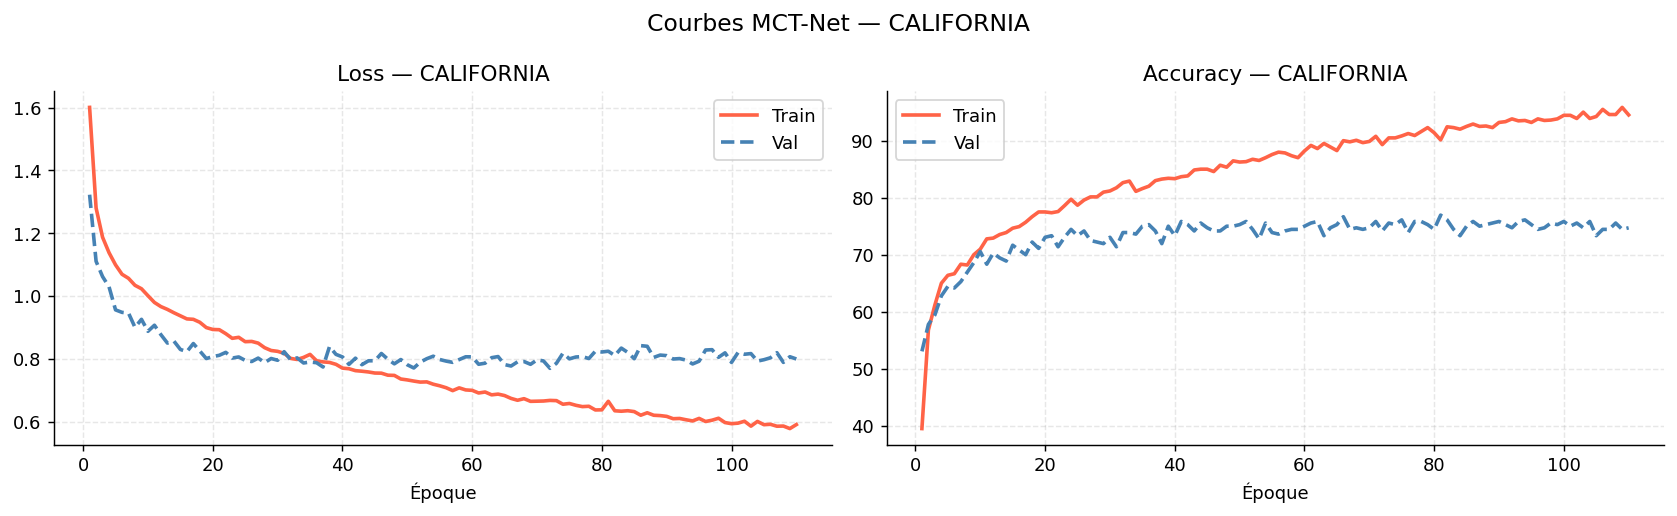

  [CALIFORNIA] Train: Loss=0.5925 Acc=94.51%  |  Val: Loss=0.8010 Acc=74.72%


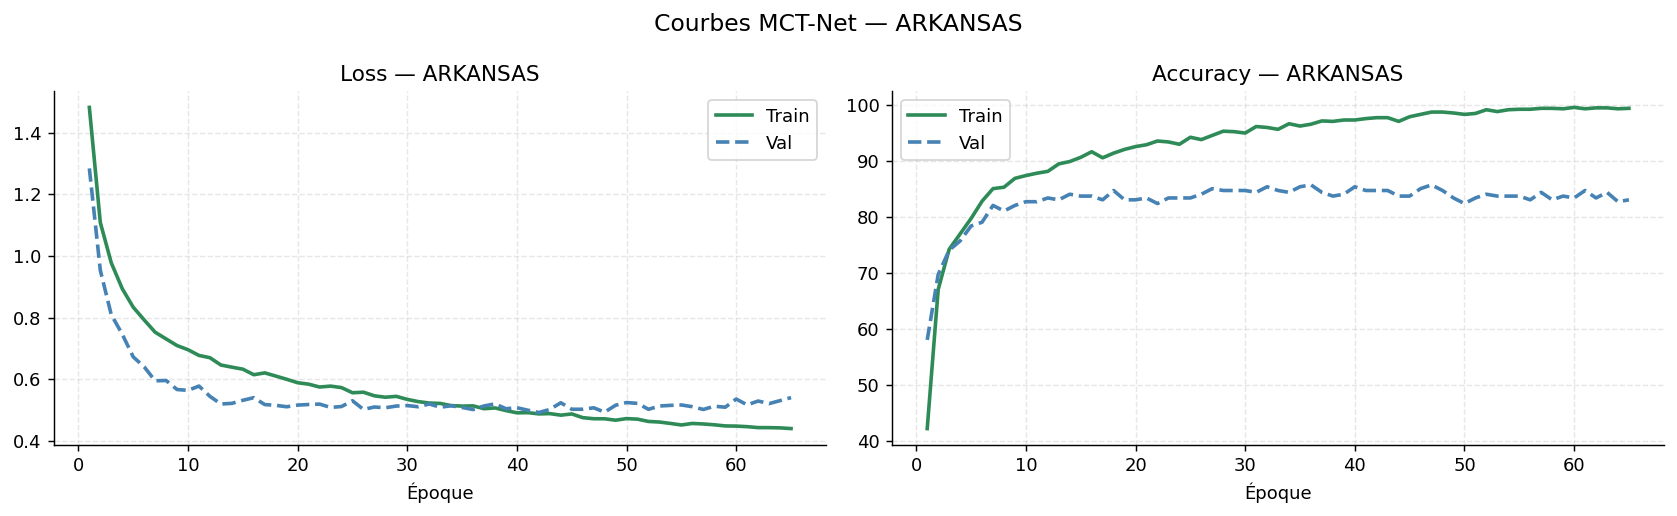

  [ARKANSAS] Train: Loss=0.4402 Acc=99.33%  |  Val: Loss=0.5406 Acc=83.00%


In [ ]:
def plot_history(history, label, color='tomato'):
    epochs = range(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, history['loss'],     color=color,      linewidth=2, label='Train')
    axes[0].plot(epochs, history['val_loss'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[0].set_title(f'Loss — {label}'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['accuracy'],     color=color,      linewidth=2, label='Train')
    axes[1].plot(epochs, history['val_accuracy'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[1].set_title(f'Accuracy — {label}'); axes[1].set_xlabel('Époque'); axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'Courbes MCT-Net — {label}', fontsize=13)
    plt.tight_layout(); plt.show()
    print(f'  [{label}] Train: Loss={history["loss"][-1]:.4f} Acc={history["accuracy"][-1]:.2f}%'
          f'  |  Val: Loss={history["val_loss"][-1]:.4f} Acc={history["val_accuracy"][-1]:.2f}%')

plot_history(history_CA, 'CALIFORNIA', color='tomato')
plot_history(history_AR, 'ARKANSAS',   color='seagreen')

### 🧪 Évaluation sur le jeu de TEST

In [ ]:
def evaluate_test(model, X_test, m_test, y_test, le, device, label):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    m_t = torch.tensor(m_test, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_test, dtype=torch.long).to(device)
    with torch.no_grad():
        outputs      = model(X_t, m_t)
        _, predicted = torch.max(outputs, 1)
        acc = 100 * (predicted == y_t).sum().item() / len(y_t)
    pred_np = predicted.cpu().numpy()
    print(f'[{label}] Accuracy TEST : {acc:.2f}%  (classes: {list(le.classes_)})')
    return acc, pred_np


test_acc_CA, pred_CA = evaluate_test(model_CA, X_test_CA, m_test_CA, y_test_CA, le_CA, DEVICE, 'CALIFORNIA')
test_acc_AR, pred_AR = evaluate_test(model_AR, X_test_AR, m_test_AR, y_test_AR, le_AR, DEVICE, 'ARKANSAS')


[CALIFORNIA] Accuracy TEST : 77.84%  (classes: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice'])
[ARKANSAS] Accuracy TEST : 81.65%  (classes: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans'])


### Profils NDVI — Fig. 2 du paper

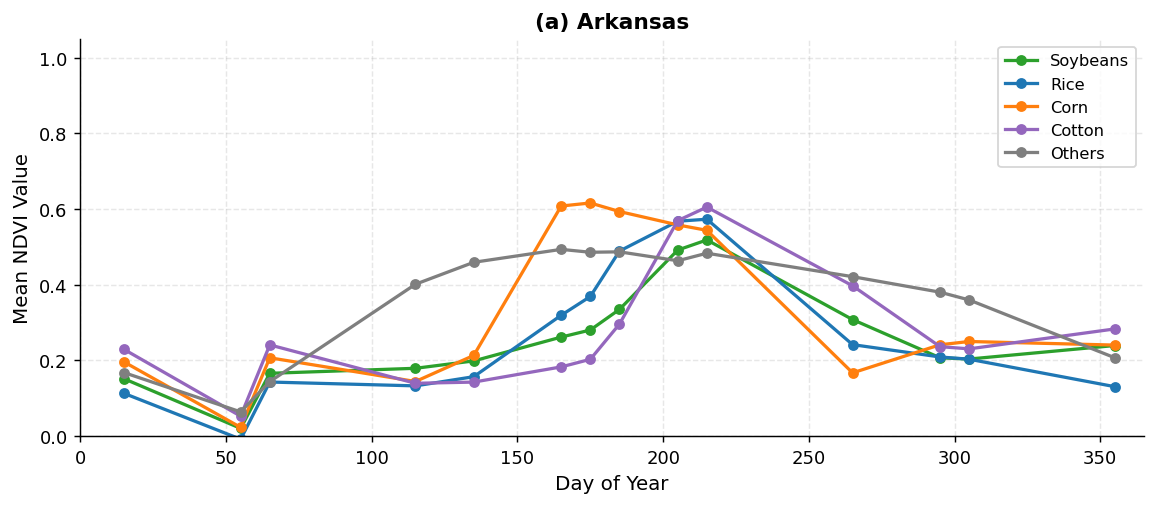

  NDVI Arkansas sauvegarde -> data\processed\ndvi_arkansas.png


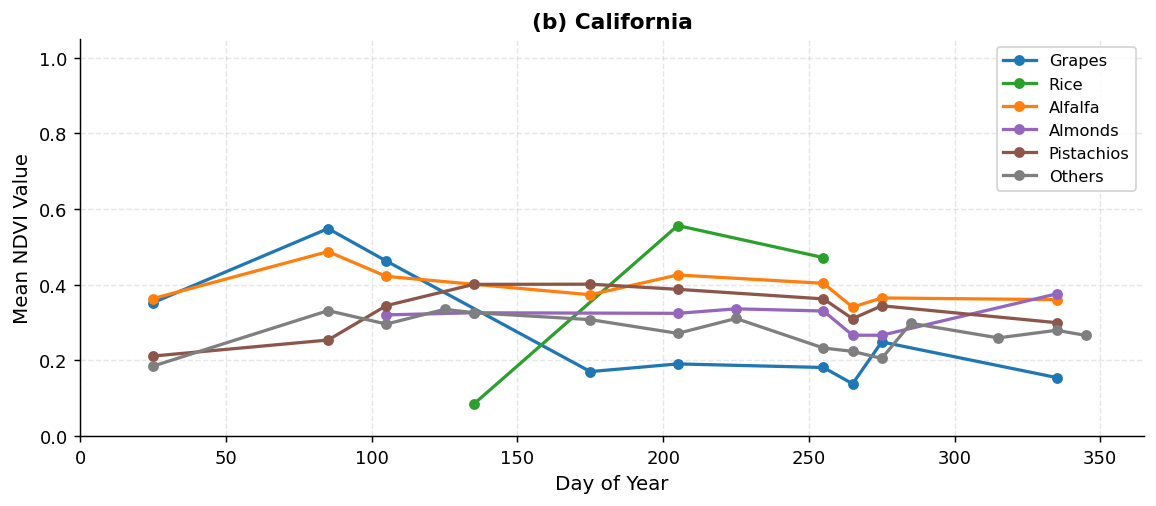

  NDVI California sauvegarde -> data\processed\ndvi_california.png


In [ ]:
CA_COLORS = {
    'Grapes':'#1f77b4','Rice':'#2ca02c','Alfalfa':'#ff7f0e',
    'Almonds':'#9467bd','Pistachios':'#8c564b','Others':'#7f7f7f'
}
AR_COLORS = {
    'Soybeans':'#2ca02c','Rice':'#1f77b4','Corn':'#ff7f0e',
    'Cotton':'#9467bd','Others':'#7f7f7f'
}

def plot_ndvi_profiles(csv_path, order, color_map, label, sub='a'):
    """Reproduit la Fig. 2 du paper : profils NDVI moyens par culture."""
    df = pd.read_csv(csv_path)
    feat_cols = [c for c in df.columns if c not in ['crop_label','split']]
    X      = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype(float)
    labels = df['crop_label'].values

    NIR  = X[:, :, IDX_NIR]
    RED  = X[:, :, IDX_RED]
    NDVI = (NIR - RED) / (NIR + RED + 1e-6)
    NDVI[(np.abs(NIR) < 1e-6) & (np.abs(RED) < 1e-6)] = np.nan

    fig, ax = plt.subplots(figsize=(9, 4))
    for cls in order:
        idx = labels == cls
        if idx.sum() == 0:
            continue
        mean_ndvi = np.nanmean(NDVI[idx], axis=0)
        coverage  = (~np.isnan(NDVI[idx])).mean(axis=0)
        valid     = coverage >= 0.1
        doys      = np.array(TARGET_DOYS)
        ax.plot(doys[valid], mean_ndvi[valid],
                marker='o', markersize=5, linewidth=1.8,
                color=color_map.get(cls, 'gray'), label=cls)

    ax.set_xlabel('Day of Year', fontsize=11)
    ax.set_ylabel('Mean NDVI Value', fontsize=11)
    ax.set_title(f'({sub}) {label}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    out_path = PROCESSED_DIR / f'ndvi_{label.lower()}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  NDVI {label} sauvegarde -> {out_path}')


plot_ndvi_profiles(TRAIN_CSV_AR, ['Soybeans','Rice','Corn','Cotton','Others'], AR_COLORS, 'Arkansas', 'a')
plot_ndvi_profiles(TRAIN_CSV_CA, CA_ORDER, CA_COLORS, 'California', 'b')


### Matrices de confusion normalisees — Fig. 7 & 8 du paper

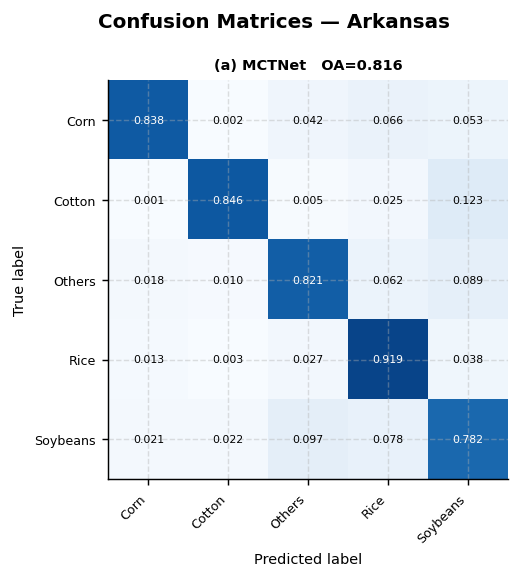

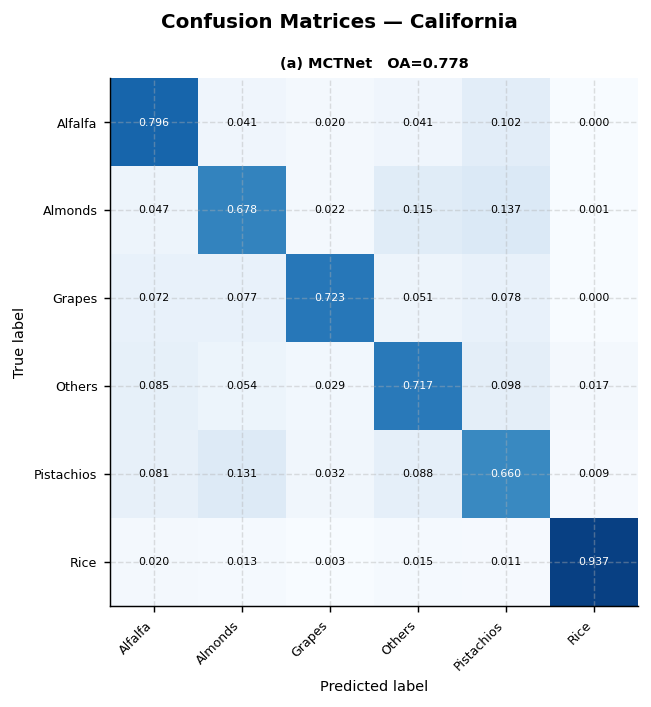

Matrices sauvegardees dans data\processed


In [35]:
def plot_confusion_matrix(y_true, y_pred, classes, title='', ax=None):
    """Matrice de confusion normalisee avec valeurs — style Fig. 7/8 du paper."""
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    n  = len(classes)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(n))
    ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel('Predicted label', fontsize=8)
    ax.set_ylabel('True label', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    for i in range(n):
        for j in range(n):
            color = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.3f}', ha='center', va='center',
                    fontsize=6, color=color)


# Arkansas — Fig. 7
fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
oa_ar = (pred_AR == y_test_AR).mean()
plot_confusion_matrix(y_test_AR, pred_AR, le_AR.classes_,
                      title=f'(a) MCTNet   OA={oa_ar:.3f}', ax=ax)
plt.suptitle('Confusion Matrices — Arkansas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_arkansas.png', dpi=150, bbox_inches='tight')
plt.show()

# California — Fig. 8
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))
oa_ca = (pred_CA == y_test_CA).mean()
plot_confusion_matrix(y_test_CA, pred_CA, le_CA.classes_,
                      title=f'(a) MCTNet   OA={oa_ca:.3f}', ax=ax)
plt.suptitle('Confusion Matrices — California', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_california.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Matrices sauvegardees dans {PROCESSED_DIR}')


### 💾 Sauvegarde du modèle

In [36]:
def save_model(model, path, num_classes, le, history, test_acc, n_dates, label):
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes'     : num_classes,
        'label_classes'   : list(le.classes_),
        'history'         : history,
        'test_accuracy'   : test_acc,
        'n_dates'         : n_dates,
        'n_bands'         : N_BANDS,
    }, path)
    print(f'✅ [{label}] Modèle sauvegardé : {path}')
    print(f'   Accuracy test : {test_acc:.2f}%')

save_model(model_CA, MODEL_PATH_CA, num_classes_CA, le_CA, history_CA, test_acc_CA, len(DATES_MAP_CA), 'CALIFORNIA')
save_model(model_AR, MODEL_PATH_AR, num_classes_AR, le_AR, history_AR, test_acc_AR, len(DATES_MAP_AR), 'ARKANSAS')

print('\n🎉 Pipeline MCT-Net complet — California + Arkansas terminé !')


✅ [CALIFORNIA] Modèle sauvegardé : models\mctnet_california_final.pth
   Accuracy test : 77.84%
✅ [ARKANSAS] Modèle sauvegardé : models\mctnet_arkansas_final.pth
   Accuracy test : 81.65%

🎉 Pipeline MCT-Net complet — California + Arkansas terminé !


Paper (idée)

* CNN branch produit features spatiales

* Transformer branch produit features temporelles

* fusion structurée (souvent projection + concat + parfois gating)

* pas de fusion gating / attention fusion

* pas de normalization post-fusion





séparation stricte CNN feature space vs Transformer embedding space



parfois shared embedding stage



learned pooling / stride conv / attention pooling



Paper MCTNet utilise souvent :





deeper encoder stack OR multi-block refinement



Je peux t’aider à améliorer 3 points clés :

1. Fusion CTFusion plus fidèle (attention fusion au lieu de concat simple)

2. Transformer multi-layer (stack de 2–3 encoders)

3. pooling appris (attention pooling au lieu de maxpool)

